# Предсказание температуры сплава

**Описание:** Проект направлен на снижение производственных расходов металлургического комбината за счет контроля температуры сплава на этапе обработки стали. Для этого разрабатывается модель машинного обучения, предсказывающая температуру стали на определенном этапе технологического процесса.

**Цель:** Обучить модель предсказания температуры стали

**Задачи:**

- провести анализ имеющихся данных
- сформировать обучающий датасет
- обучить несколько моделей регрессии и выбрать лучшую
- интерпретировать модель

**Описание данных от заказчика:**

Данные хранятся в СУБД Sqlite. Они представлены несколькими таблицами:

- data_arc — данные об электродах
  - key — номер партии
  - BeginHeat — время начала нагрева
  - EndHeat — время окончания нагрева
  - ActivePower — значение активной мощности
  - ReactivePower — значение реактивной мощности
<br> 

- data_bulk — данные об объёме сыпучих материалов
  - key — номер партии
  - Bulk1 … Bulk15 — объём подаваемого материала
<br>

- data_bulk_time — данные о времени подачи сыпучих материалов
  - key — номер партии
  - Bulk1 … Bulk15 — время подачи материала
<br>

- data_gas — данные о продувке сплава газом
  - key — номер партии
  - gas — объём подаваемого газа
 <br>

- data_temp — данные об измерениях температуры
  - key — номер партии
  - MesaureTime — время замера
  - Temperature — значение температуры
<br>

- data_wire — данные об объёме проволочных материалов
  - key — номер партии
  - Wire1 … Wire9 — объём подаваемых проволочных материалов
<br>

- data_wire_time — данные о времени подачи проволочных материалов
  - key — номер партии
  - Wire1 … Wire9 — время подачи проволочных материалов

In [1]:
!pip install phik==0.12.5 -q
!pip install --upgrade scikit-learn==1.6.1 -q
!pip install catboost==1.0.3 -q
!pip install --upgrade --no-cache-dir skorch==1.2.0 -q
!pip install --upgrade shap==0.49.1 -q
!pip install --no-cache-dir numba==0.56.4 -q

In [2]:
import math
import os
import random
import urllib.request
from contextlib import contextmanager
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
import shap
import torch
import torch.nn as nn
from catboost import CatBoostRegressor, Pool
from skorch import NeuralNetRegressor
from skorch.callbacks import Callback, EarlyStopping, LRScheduler
from skorch.dataset import ValidSplit
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sqlalchemy import create_engine, inspect

from IPython.display import Markdown, display, clear_output

In [3]:
RANDOM_STATE = 200726
TEST_SIZE = 0.25

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cpu'

## Загрузка данных

Загрузим данные

In [4]:
url = 'https://code.s3.yandex.net/data-scientist/ds-plus-final.db'
path_to_db = 'ds-plus-final.db'

if not os.path.exists(path_to_db):
    urllib.request.urlretrieve(url, path_to_db)

In [5]:
engine = create_engine(f'sqlite:///{path_to_db}', echo=False) 
inspector = inspect(engine)

Осмотрим имеющиеся в базе данных таблицы

In [6]:
tables = inspector.get_table_names()
tables

['contract',
 'data_arc',
 'data_bulk',
 'data_bulk_time',
 'data_gas',
 'data_temp',
 'data_wire',
 'data_wire_time',
 'internet',
 'personal',
 'phone']

In [7]:
for table in tables:
    query = f'SELECT COUNT(*) as count FROM {table}'
    count_df = pd.read_sql(query, engine)
    rows_count = count_df['count'].iloc[0]
    print(f'Количество строк в таблице "{table}": {rows_count}')

Количество строк в таблице "contract": 7043
Количество строк в таблице "data_arc": 14876
Количество строк в таблице "data_bulk": 3129
Количество строк в таблице "data_bulk_time": 3129
Количество строк в таблице "data_gas": 3239
Количество строк в таблице "data_temp": 18092
Количество строк в таблице "data_wire": 3081
Количество строк в таблице "data_wire_time": 3081
Количество строк в таблице "internet": 5517
Количество строк в таблице "personal": 7043
Количество строк в таблице "phone": 6361


В базе содержатся необходимые согласно ТЗ таблицы, все они не пусты. Помимо необходимых таблиц присуствуют также `contract`, `internet`, `personal` и `phone` (предположительно не относящиеся к тех процессу).

Осмотрим поля и первые строки каждой из таблиц

In [8]:
for table in tables:
    print('\n')
    display(Markdown(f'*Таблица:* ***{table}***'))
    display(pd.read_sql(table, engine).head(3))

*Таблица:* ***contract***

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17


*Таблица:* ***data_arc***

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


*Таблица:* ***data_bulk***

...

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No


*Таблица:* ***personal***

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No


*Таблица:* ***phone***

,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No


Убедились, что содержимое таблиц `contract`, `internet`, `personal` и `phone` действительно не относится к тех процессу.

In [9]:
tables = [
    table for table in tables
    if table not in {'contract', 'internet', 'personal', 'phone'}
]
tables

['data_arc',
 'data_bulk',
 'data_bulk_time',
 'data_gas',
 'data_temp',
 'data_wire',
 'data_wire_time']

Загрузим все необходимые таблицы в датафреймы. Для некоторых полей по имени не ясно, действительно ли в них должна быть дата. При загрузке данных укажем тип дата/время только для тех полей, относительно которых уверены. С остальными датами будем разбираться в процессе EDA

In [10]:
def load_table(table: str, db_engine = engine, parse_dates = None) -> pd.DataFrame:
    return pd.read_sql(table, db_engine, parse_dates=parse_dates)

In [11]:
data_arc_df = load_table('data_arc', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
data_bulk_df = load_table('data_bulk')
data_bulk_time_df = load_table('data_bulk_time')
data_gas_df = load_table('data_gas')
data_temp_df = load_table('data_temp', parse_dates=['Время замера'])
data_wire_df = load_table('data_wire')
data_wire_time_df = load_table('data_wire_time')

In [12]:
summary_data = []
all_dfs = {
    'data_arc': data_arc_df,
    'data_bulk': data_bulk_df,
    'data_bulk_time': data_bulk_time_df,
    'data_gas': data_gas_df,
    'data_temp': data_temp_df,
    'data_wire': data_wire_df,
    'data_wire_time': data_wire_time_df
}

for name, df in all_dfs.items():
    summary_data.append({
        'Таблица': name,
        'Строк': df.shape[0],
        'Столбцов': df.shape[1],
        'Явные дубликаты': df.duplicated().sum(),
        'Строки с пропусками': df.isna().any(axis=1).sum(),
        'Типы данных': ', '.join([str(t) for t in df.dtypes.unique()])
    })

display(Markdown('***Сводная информация по датафреймам***'))
display(pd.DataFrame(summary_data))

***Сводная информация по датафреймам***

,Таблица,Строк,Столбцов,Явные дубликаты,Строки с пропусками,Типы данных
0,data_arc,14876,5,0,0,"int64, datetime64[ns], float64"
1,data_bulk,3129,16,0,3129,"int64, float64, object"
2,data_bulk_time,3129,16,0,3129,"int64, object"
3,data_gas,3239,2,0,0,"int64, float64"
4,data_temp,18092,3,0,3427,"int64, datetime64[ns], object"
5,data_wire,3081,10,0,3081,"int64, float64, object"
6,data_wire_time,3081,10,0,3081,"int64, object"


**В базе данных присутствуют все необходимые таблицы. Имена полей отличаются от указанных в ТЗ, однако по смыслу они соответствуют.**

**Все необходимые таблицы загружены в датафреймы. При первичном осмотре явные дубликаты строк не обнаружены, выявлено наличие пропущенных значений.**

**Количество строк в датафреймах:**
- data_arc_df: 14876
- data_bulk_df: 3129
- data_bulk_time_df: 3129
- data_gas_df: 3239
- data_temp_df: 18092
- data_wire_df: 3081
- data_wire_time_df: 3081

## Исследовательский анализ

Вспомогательные фукнции

In [13]:
def df_info(df: pd.DataFrame):
    display(Markdown('**Размер датафрейма**'), df.shape)
    display(Markdown('**Информация о датафрейме**'))
    df.info()
    display(Markdown(f'**Количество явных дубликатов строк: {df.duplicated().sum()}**'))
    display(Markdown(f'**Количество строк с пропущенными значениями: {df.isna().any(axis=1).sum()}**'))
    display(Markdown('**Первые строки датафрейма**'), df.head())

In [14]:
def draw_hist_boxplot(df: pd.DataFrame, cols: Union[list[str], str], bins=30, title=None, height_scale=1):
    if isinstance(cols, str):
        cols = [cols]
    nrows = len(cols)
    plt.figure(figsize=(16, nrows * 2 * height_scale))
    
    for i, col in enumerate(cols):
        plt.subplot(nrows, 2, i*2 + 1)
        plt.hist(df[col], bins=bins)
        plt.title(f'{col} histogramm')
        plt.xlabel(col)
        plt.ylabel('Count')
    
        plt.subplot(nrows, 2, i*2 + 2)
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(f'{col} boxplot')
        plt.xlabel(col)

    if title is not None:
        plt.suptitle(title, fontsize=16, y=1.01)
    
    plt.tight_layout()
    plt.show()

In [15]:
@contextmanager
def track_size(name: str):
    """Контекстный менеджер для отслеживания размера датафрейма."""
    df = globals().get(name)
    if df is None:
        raise NameError(f'"{name}" not found')
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f'"{name}" is not DataFrame')
    print(f'Датафрейм {name}')
    print(f'Строк до: {(rows := df.shape[0])}')
    try:
        yield
    finally:
        df = globals().get(name)
        print(f'Строк после: {df.shape[0]}. Удалено {rows - df.shape[0]}')

### data_arc (данные об электродах)

Изучим датафрейм с данными об электродах

In [16]:
data_arc_df.columns

Index(['key', 'Начало нагрева дугой', 'Конец нагрева дугой',
       'Активная мощность', 'Реактивная мощность'],
      dtype='object')

Переименуем колонки

In [17]:
data_arc_df = data_arc_df.rename(columns={
    'key': 'key',
    'Начало нагрева дугой': 'begin_heat',
    'Конец нагрева дугой': 'end_heat',
    'Активная мощность': 'active_power',
    'Реактивная мощность': 'reactive_power'
})
data_arc_df.columns

Index(['key', 'begin_heat', 'end_heat', 'active_power', 'reactive_power'], dtype='object')

In [18]:
df_info(data_arc_df)

**Размер датафрейма**

(14876, 5)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   key             14876 non-null  int64         
 1   begin_heat      14876 non-null  datetime64[ns]
 2   end_heat        14876 non-null  datetime64[ns]
 3   active_power    14876 non-null  float64       
 4   reactive_power  14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 0**

**Первые строки датафрейма**

,key,begin_heat,end_heat,active_power,reactive_power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


Типы данных корректны, явные дубликаты строк и пропуски не наблюдаются

Осмотрим признаки времени

In [19]:
data_arc_df.select_dtypes(include=['datetime64']).agg(['min', 'max']).T

,min,max
begin_heat,2019-05-03 11:02:14,2019-09-06 17:24:54
end_heat,2019-05-03 11:06:02,2019-09-06 17:26:15


Убедимся, что `end_heat` всегда позже `begin_heat`

In [20]:
(data_arc_df['begin_heat'] >= data_arc_df['end_heat']).sum()

0

Убедимся, что у каждой партии не возникает аномалий с началом следующей итерации до окончания текущей

In [21]:
data_arc_df.sort_values(['key', 'begin_heat']).pipe(
    lambda df: df.groupby('key')['begin_heat'].shift(-1) <= df['end_heat']
).sum()

0

Отсортируем датафрейм по `begin_heat` для каждого `key`

In [22]:
data_arc_df = data_arc_df.sort_values(by=['key', 'begin_heat'])

Изучим числовые признаки

In [23]:
data_arc_df.describe().T

,count,mean,std,min,25%,50%,75%,max
key,14876.0,1615.220422,934.571502,1.000000,806.000000,1617.000000,2429.000000,3241.000000
active_power,14876.0,0.662752,0.258885,0.223120,0.467115,0.599587,0.830070,1.463773
reactive_power,14876.0,0.438986,5.873485,-715.479924,0.337175,0.441639,0.608201,1.270284


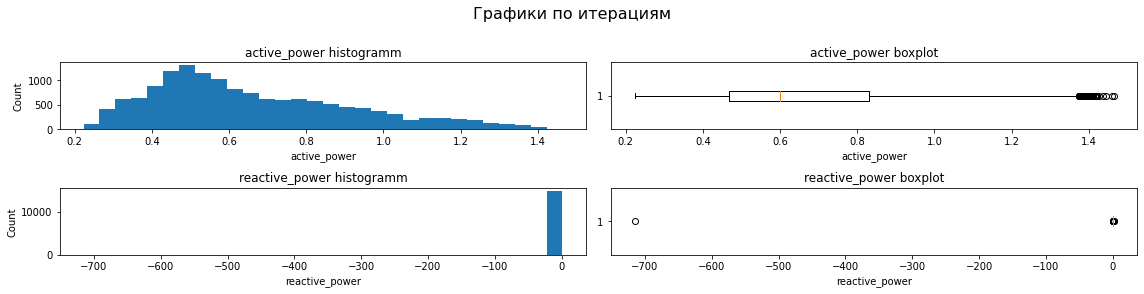

In [24]:
draw_hist_boxplot(data_arc_df, ['active_power', 'reactive_power'], title='Графики по итерациям')

Признак `active_power` находится в диапазоне от 0.223120 до 1.463773 (данные о размерности отсутствуют, предположительно МВт). Наблюдаются выбросы, которые нет оснований считать аномальными. Распределение скошено (вправо).

У признака `reactive_power` наблюдается как минимум одно аномальное значение.

Устраним из датафрейма всю партию с аномальным значением

In [25]:
(data_arc_df['reactive_power'] < -600).sum()

1

In [26]:
with track_size('data_arc_df'):
    data_arc_df = data_arc_df[
        ~data_arc_df['key'].isin(
            data_arc_df[data_arc_df['reactive_power'] < -600]['key']
        )
    ].reset_index(drop=True)

Датафрейм data_arc_df
Строк до: 14876
Строк после: 14872. Удалено 4


Повторно отобразим графики для признака `reactive_power`

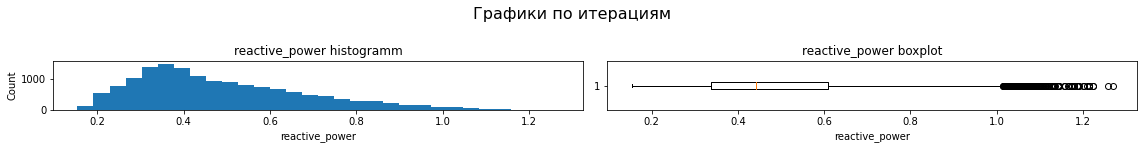

In [27]:
draw_hist_boxplot(data_arc_df, 'reactive_power', title='Графики по итерациям')

In [28]:
data_arc_df['reactive_power'].min()

0.153777

Диапазон значений признака `reactive_power` от 0.153777 до 1.270284 (предположительно МВАр). Выбросы присутствуют, оснований считать их аномальными нет. Распределение скошено (вправо).

Сгенерируем дополнительные признаки, которые могут оказаться полезны:
- продолжительность нагрева (`heat_duration`) (секунды)
- активная энергия (`active_energy`) (МВт*с)
- реактивная энергия (`reactive_energy`) (МВАр*с)
- общая мощность (`total_power`) (МВА)
- полная энергия (`total_energy`) (МВА*с)
- соотношение активной мощности к реактивной (`power_rate`)
- количество запусков нагрева электродами (`heat_count`)
- время первого нагрева в партии (`heat_start_time`)
- время последнего нагрева в партии (`heat_end_time`)

**Поскольку продолжительность нагрева у разных итераций различается, простое суммирование значений активной, реактивной или общей мощностей при группировке будет не совсем корректным. Рассчитаем значения активной и реактивной мощностей уже после группировки как отношение активной/реактивной энергии к времени, на их основе рассчитаем полную мощность. Полную энегрию рассчитаем на основе полной мощности после группировки.
Отношение активной мощности к реактивной также рассчитаем после группировки.**

`heat_start_time` и `heat_end_time` понадобятся для валидации данных на адекватность после объединения датафреймов

Для начала создадим признаки `heat_duartion`, `active_energy`, `reactive_energy`.

In [29]:
data_arc_df['heat_duration'] = (data_arc_df['end_heat'] - data_arc_df['begin_heat']).dt.total_seconds()
data_arc_df['active_energy'] = data_arc_df['active_power'] * data_arc_df['heat_duration']
data_arc_df['reactive_energy'] = data_arc_df['reactive_power'] * data_arc_df['heat_duration']

In [30]:
data_arc_df[['heat_duration', 'active_energy', 'reactive_energy']].describe().T

,count,mean,std,min,25%,50%,75%,max
heat_duration,14872.0,171.688004,98.193604,11.000000,107.000000,147.000000,214.000000,907.000000
active_energy,14872.0,114.055512,83.013658,5.246505,57.376903,92.202561,145.987744,898.200876
reactive_energy,14872.0,83.760479,61.666643,3.566134,41.885407,67.548320,106.993962,635.262558


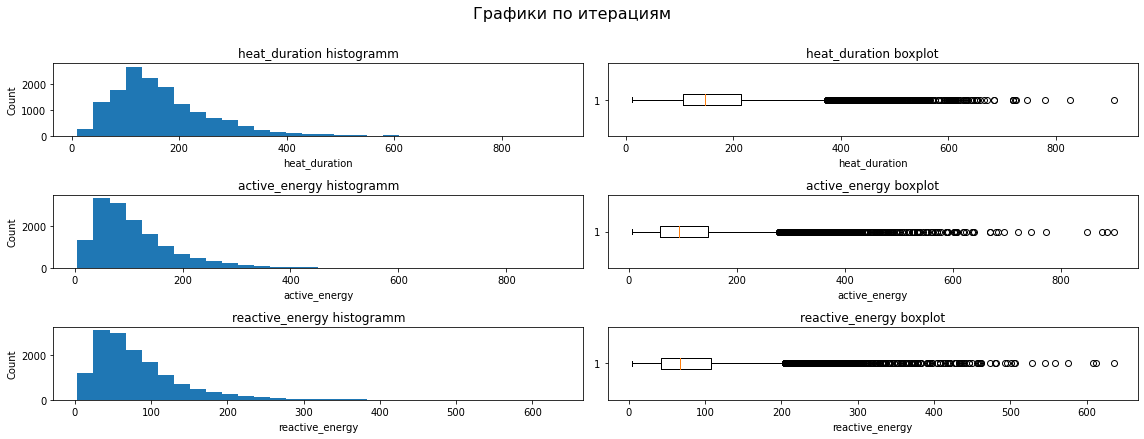

In [31]:
draw_hist_boxplot(data_arc_df, ['heat_duration', 'active_energy', 'reactive_energy'], title='Графики по итерациям')

Признак `heat_duartion` находится в диапазоне от 11 секунд до 907 секунд (или до 15 минут). 

Выбросы наблюдаются у всех трех признаков, нет оснований считать их аномальными. Распределения скошены (вправо).

Получим итоговые данные для партии, сгруппировав данные по ключу (номеру партии).

In [32]:
data_arc_grouped = data_arc_df.groupby('key').agg(
    heat_duration=('heat_duration', 'sum'),
    active_energy=('active_energy', 'sum'),
    reactive_energy=('reactive_energy', 'sum'),
    heat_count=('key', 'count'),
    heat_start_time=('begin_heat', 'first'),
    heat_end_time=('end_heat', 'last'),
).reset_index()

Теперь добавим `active_power`, `reactive_power`, `total_power`, `power_rate` и `total_energy`

In [33]:
data_arc_grouped['active_power'] = data_arc_grouped['active_energy'] / data_arc_grouped['heat_duration']
data_arc_grouped['reactive_power'] = data_arc_grouped['reactive_energy'] / data_arc_grouped['heat_duration']
data_arc_grouped['total_power'] = (data_arc_grouped['active_power'] ** 2 +  data_arc_grouped['reactive_power'] ** 2) ** 0.5
data_arc_grouped['power_rate'] = data_arc_grouped['active_power'] / data_arc_grouped['reactive_power']
data_arc_grouped['total_energy'] = data_arc_grouped['total_power'] * data_arc_grouped['heat_duration']

In [34]:
data_arc_grouped.head()

,key,heat_duration,active_energy,reactive_energy,heat_count,heat_start_time,heat_end_time,active_power,reactive_power,total_power,power_rate,total_energy
0,1,1098.0,628.616930,444.489437,5,2019-05-03 11:02:14,2019-05-03 11:28:37,0.572511,0.404817,0.701175,1.414245,769.889670
1,2,811.0,395.281800,274.689995,4,2019-05-03 11:34:14,2019-05-03 11:53:18,0.487400,0.338705,0.593532,1.439011,481.354646
2,3,655.0,581.774624,428.038924,5,2019-05-03 12:06:54,2019-05-03 12:32:19,0.888206,0.653495,1.102708,1.359163,722.273517
3,4,741.0,543.710274,413.941977,4,2019-05-03 12:39:37,2019-05-03 12:57:50,0.733752,0.558626,0.922201,1.313494,683.351171
4,5,869.0,412.180480,303.070918,4,2019-05-03 13:11:13,2019-05-03 13:33:55,0.474316,0.348758,0.588734,1.360013,511.609939


Изучим признаки в датафрейме после группировки

In [35]:
data_arc_grouped[
    [
        'heat_duration', 'active_energy', 'reactive_energy', 'heat_count',
        'active_power', 'reactive_power', 'total_power', 'power_rate', 'total_energy'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
heat_duration,3213.0,794.691566,332.439136,57.000000,571.000000,770.000000,983.000000,4189.000000
active_energy,3213.0,527.928285,248.751648,26.187544,358.825785,498.897459,669.181550,3718.054401
reactive_energy,3213.0,387.701786,183.489942,20.779589,264.636828,366.440708,488.189344,2612.081299
heat_count,3213.0,4.628696,1.608860,1.000000,4.000000,4.000000,6.000000,16.000000
active_power,3213.0,0.662509,0.139532,0.267676,0.560313,0.649993,0.749707,1.259114
reactive_power,3213.0,0.486606,0.106511,0.196228,0.408698,0.476844,0.553739,0.963734
total_power,3213.0,0.822293,0.174217,0.331897,0.692084,0.807656,0.931485,1.567228
power_rate,3213.0,1.365604,0.074110,1.094437,1.316650,1.366732,1.415017,1.663366
total_energy,3213.0,655.193562,308.687879,33.430208,444.564828,619.772266,827.323864,4543.885699


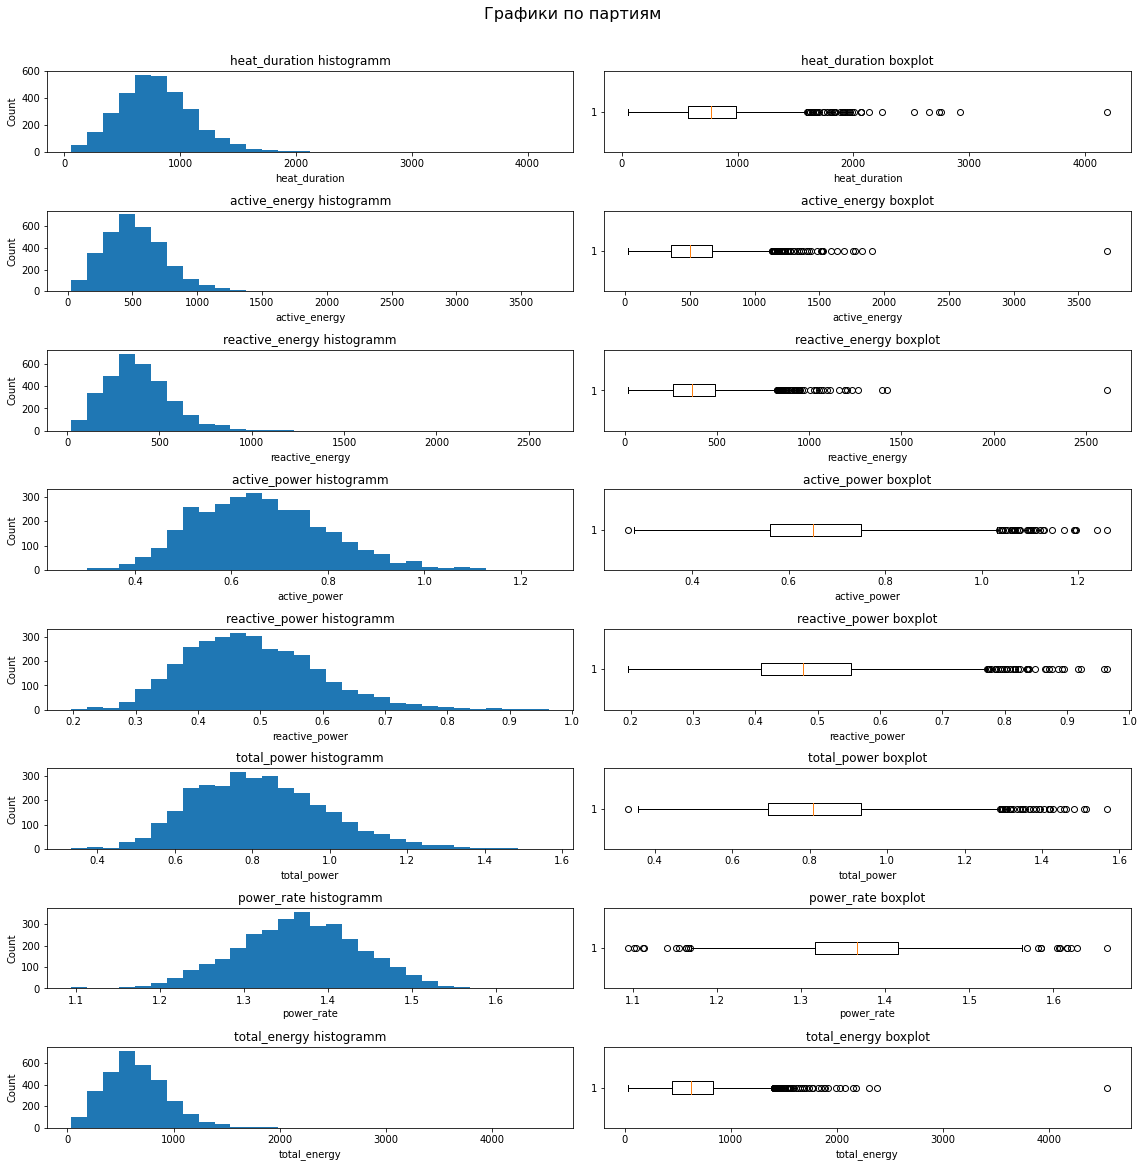

In [36]:
draw_hist_boxplot(
    data_arc_grouped,
    [
        'heat_duration', 'active_energy', 'reactive_energy', 'active_power',
        'reactive_power', 'total_power', 'power_rate', 'total_energy'
    ],
    title='Графики по партиям'
)

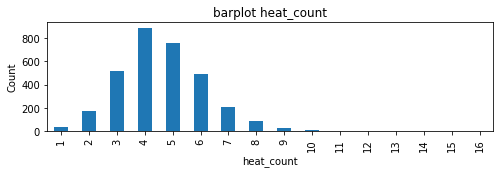

In [37]:
data_arc_grouped['heat_count'].value_counts().sort_index().plot(kind='bar', figsize=(8, 2))
plt.title('barplot heat_count')
plt.xlabel('heat_count')
plt.ylabel('Count')
plt.show()

Количество итераций нагрева в рамках одной партии может быть от 1 до 16. Чаще всего от 3 до 6.

Общая продолжительность нагрева для одной партии составляет от 57 секунд (минута) до 4189 секунд (более часа)

У всех признаков можем наблюдать выбросы (а именно отклонение более чем на 1.5 IQR от 1 или 3 квартиля). Нет оснований считать их аномальными. Удаление записей с не аномальными выбросами допустимо при обучении модели (и может улучшить ее качество), но **поскольку у нас отсутствует заранее подготовленная тестовая выборка (ее создание предполагается в дальнейшем), то удаление выбросов на данном этапе может привести к искусственно завышенной оценке качества модели на тестовой выборке. Поэтому пока не трогаем их.**

**Сформирован датафрейм `data_arc_grouped` с агрегированными по номеру партии признаками**

### data_bulk (данные о сыпучих материалах)

Изучим датафрейм с данными о сыпучих материалах

In [38]:
data_bulk_df.columns

Index(['key', 'Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5', 'Bulk 6',
       'Bulk 7', 'Bulk 8', 'Bulk 9', 'Bulk 10', 'Bulk 11', 'Bulk 12',
       'Bulk 13', 'Bulk 14', 'Bulk 15'],
      dtype='object')

Переименуем колонки

In [39]:
data_bulk_df.columns = data_bulk_df.columns.str.strip().str.replace(" ", "_").str.lower()
data_bulk_df.columns

Index(['key', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')

In [40]:
df_info(data_bulk_df)

**Размер датафрейма**

(3129, 16)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     object 
 6   bulk_6   576 non-null    object 
 7   bulk_7   25 non-null     object 
 8   bulk_8   1 non-null      object 
 9   bulk_9   19 non-null     object 
 10  bulk_10  176 non-null    object 
 11  bulk_11  177 non-null    object 
 12  bulk_12  2450 non-null   object 
 13  bulk_13  18 non-null     object 
 14  bulk_14  2806 non-null   object 
 15  bulk_15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.2+ KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 3129**

**Первые строки датафрейма**

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaN,NaN,NaN,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,NaN,NaN,NaN,81.0,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,NaN,NaN,NaN,78.0,None,None,None,None,None,None,None,203.0,None,151.0,152.0


Ожидается, что все признаки имеют числовой тип. Однако видим, что у части признаков он строковый. Попробуем преобразовать к числовому (без подавления ошибки при преобразовании - если ошибок не возникнет, значит все непустые значения являются чиcлами)

In [41]:
obj_cols = data_bulk_df.select_dtypes(include='object').columns
data_bulk_df[obj_cols] = data_bulk_df[obj_cols].astype('float')

In [42]:
data_bulk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     float64
 6   bulk_6   576 non-null    float64
 7   bulk_7   25 non-null     float64
 8   bulk_8   1 non-null      float64
 9   bulk_9   19 non-null     float64
 10  bulk_10  176 non-null    float64
 11  bulk_11  177 non-null    float64
 12  bulk_12  2450 non-null   float64
 13  bulk_13  18 non-null     float64
 14  bulk_14  2806 non-null   float64
 15  bulk_15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


Преобразование типов прошло успешно.

Видим большое количество пропущенных значений - они означают, что материал не подавался, поэтому можем заменить на нули.

Однако некоторые признаки имеют крайне мало ненулевых значений.

`bulk_8` имеет всего одно ненулевое значение. Этого недостаточно для выявления закономерностей - удалим этот признак.

In [43]:
data_bulk_df = data_bulk_df.drop(columns=['bulk_8'])

С признаками, имеющими по 20-30 ненулевых значений, ситуация менее однозначана. С одной стороны имеем мало ненулевых значений для выявления закономерностей. С другой добавление какого-то конкретного материала в значимых объемах может оказать существенное влияние на результат. Посмотрим на объемы подаваемых материалов

In [44]:
data_bulk_df.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.00,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.00,31.0,46.00,185.0
bulk_2,22.0,253.045455,21.180578,228.0,242.00,251.5,257.75,325.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.00,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.00,102.0,133.00,281.0
bulk_5,77.0,107.025974,81.790646,11.0,70.00,86.0,132.00,603.0
bulk_6,576.0,118.925347,72.057776,17.0,69.75,100.0,157.00,503.0
bulk_7,25.0,305.600000,191.022904,47.0,155.00,298.0,406.00,772.0
bulk_9,19.0,76.315789,21.720581,63.0,66.00,68.0,70.50,147.0
bulk_10,176.0,83.284091,26.060347,24.0,64.00,86.5,102.00,159.0


Видим, что объемы редко подаваемых материалов значимы (сопоставимы с объемами остальных материалов). Пока оставляем такие признаки. Однако нужно учитывать, что возникает риск выявления ложных закономерностей на редких наблюдениях из-за флуктуаций в имеющейся выборке. В любом случае после обучения модели будем производить оценку важности признаков.

In [45]:
data_bulk_df['key'].duplicated().sum()

0

Все `key` в датафрейме уникальны, то есть каждой партии соответствует одна строка. Дополнительная группировка данных по партиям не требуется.

Построим гистограммы и боксплоты. **Строим графики без предварительного заполнения пропущенных значений нулями, чтобы увидеть распределения только в случаях, когда материал подавался.**

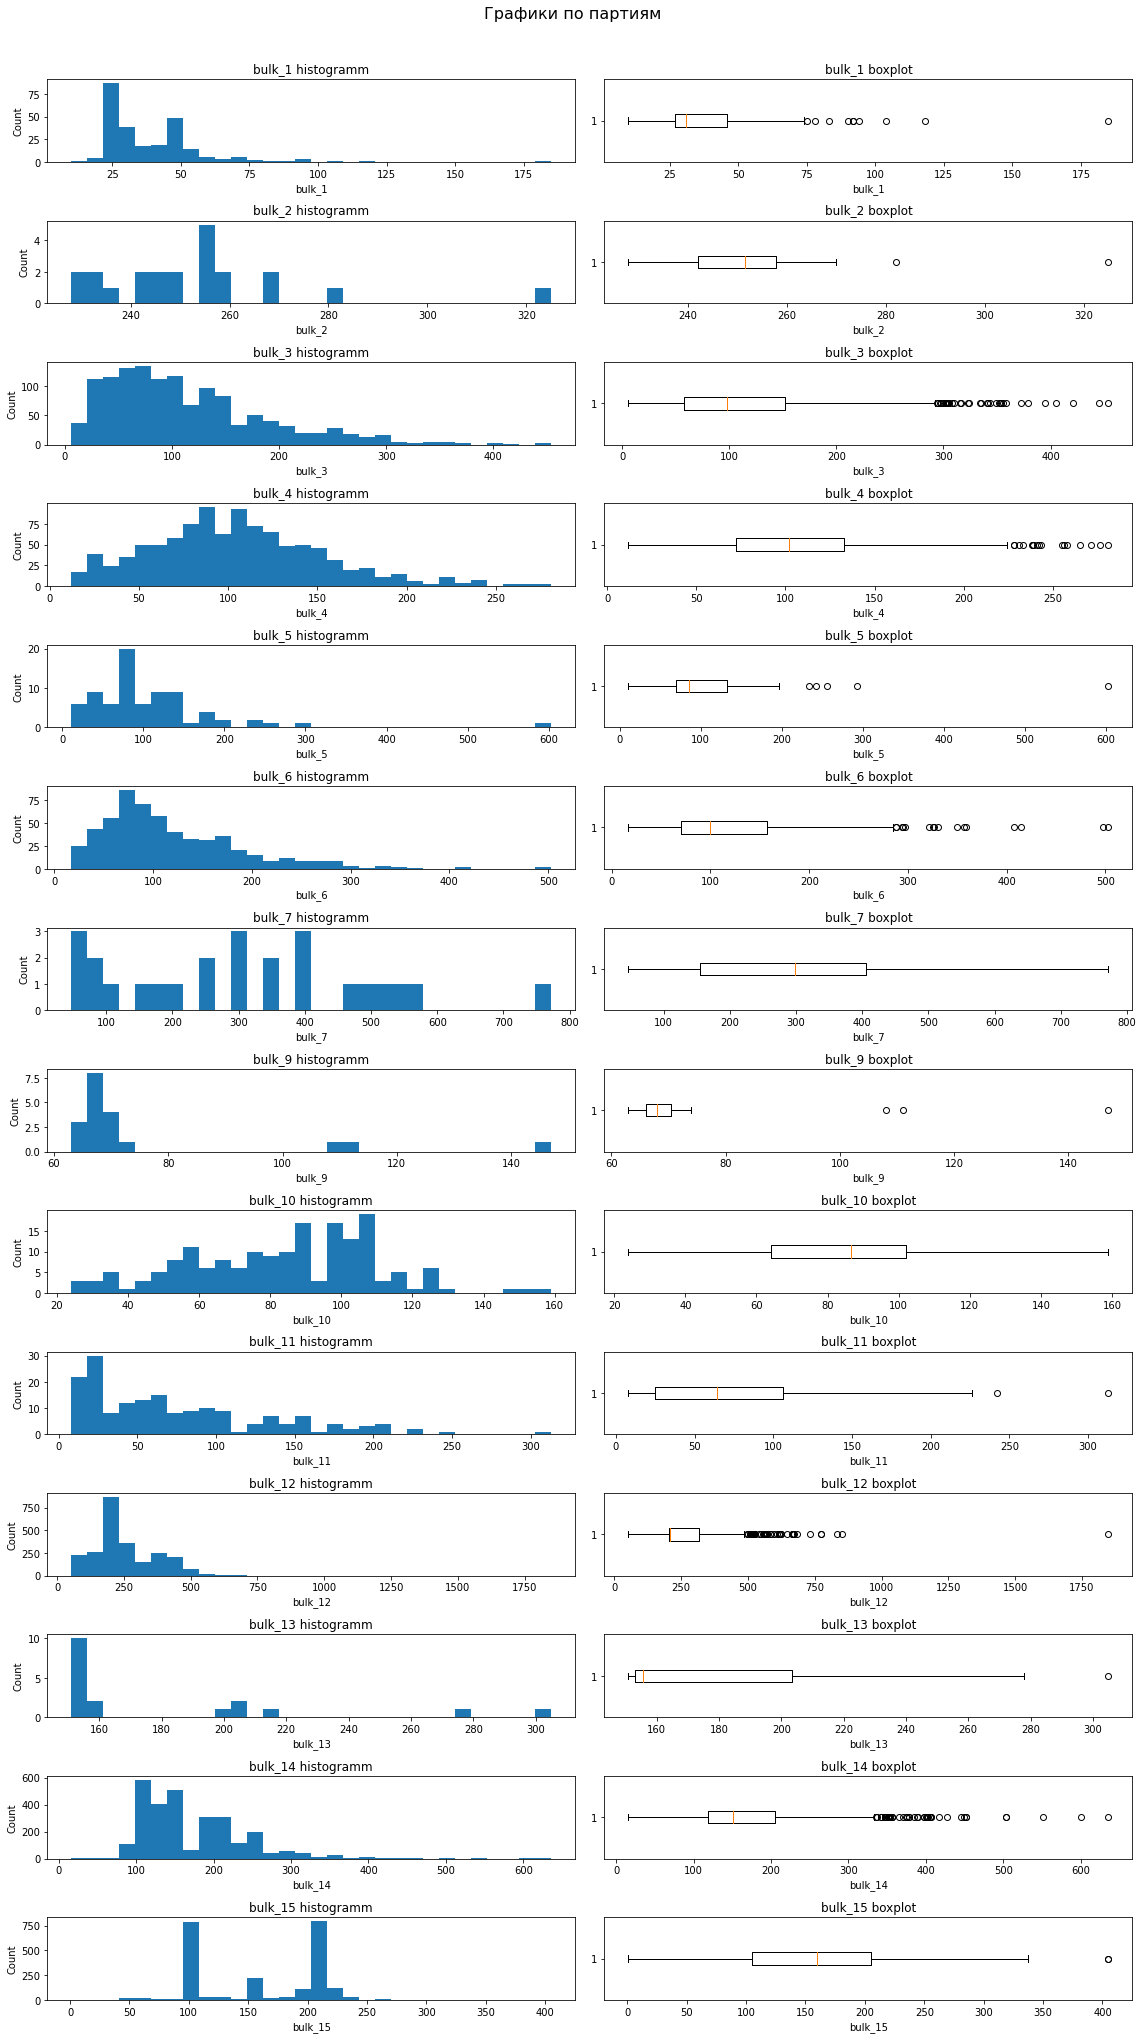

In [46]:
draw_hist_boxplot(
    data_bulk_df,
    data_bulk_df.columns.drop('key').tolist(),
    title='Графики по партиям'
)

Можем наблюдать выбросы в объемах большинства подаваемых материалов. Оснований считать их аномальными нет.

**Пропуски на данном этапе не заполняем нулями, сделаем это в пайплайне**

### data_bulk_time (время подачи сыпучих материалов)

Изучим данные о времени подачи сыпучих материалов

In [47]:
data_bulk_time_df.columns

Index(['key', 'Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5', 'Bulk 6',
       'Bulk 7', 'Bulk 8', 'Bulk 9', 'Bulk 10', 'Bulk 11', 'Bulk 12',
       'Bulk 13', 'Bulk 14', 'Bulk 15'],
      dtype='object')

Переименуем колонки

In [48]:
data_bulk_time_df.columns = data_bulk_time_df.columns.str.strip().str.replace(" ", "_").str.lower()
data_bulk_time_df.columns

Index(['key', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')

In [49]:
df_info(data_bulk_time_df)

**Размер датафрейма**

(3129, 16)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 3129**

**Первые строки датафрейма**

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


Предположительно все поля содержат даты. Попробуем преобразовать типы, не подавляя возможные ошибки при преобразовании

In [50]:
date_cols = data_bulk_time_df.columns.drop('key')

data_bulk_time_df[date_cols] = data_bulk_time_df[date_cols].apply(
    pd.to_datetime, errors='raise'
)

In [51]:
data_bulk_time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   bulk_1   252 non-null    datetime64[ns]
 2   bulk_2   22 non-null     datetime64[ns]
 3   bulk_3   1298 non-null   datetime64[ns]
 4   bulk_4   1014 non-null   datetime64[ns]
 5   bulk_5   77 non-null     datetime64[ns]
 6   bulk_6   576 non-null    datetime64[ns]
 7   bulk_7   25 non-null     datetime64[ns]
 8   bulk_8   1 non-null      datetime64[ns]
 9   bulk_9   19 non-null     datetime64[ns]
 10  bulk_10  176 non-null    datetime64[ns]
 11  bulk_11  177 non-null    datetime64[ns]
 12  bulk_12  2450 non-null   datetime64[ns]
 13  bulk_13  18 non-null     datetime64[ns]
 14  bulk_14  2806 non-null   datetime64[ns]
 15  bulk_15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.2 KB


Преобразование типов прошло успешно.

Можем заметить, что количество пропусков каждого признака в точности соответствует количеству пропусков у соответствующих признаков в датафрейме с данными об объеме подаваемого материала, что косвенно говорит о соответствии данных

In [52]:
data_bulk_time_df['key'].duplicated().sum()

0

Как и в датафрейме `data_bulk_df`, каждой партии соответствует одна строка

Сформируем датафрейм с признаками:

- `bulk_first_time` время первой подачи материала
- `bulk_last_time` время последней подачи материала
- `bulk_period` время между первой и последней подачей материала в секундах

Даты сами по себе даты малоинформативны для моделей, `bulk_first_time` и `bulk_last_time` будут использоваться для проверки данных на адекватность после объединения датафреймов

In [53]:
bulk_time_features = data_bulk_time_df[['key']].copy()

date_cols = data_bulk_time_df.columns.drop('key')

bulk_time_features['bulk_first_time'] = data_bulk_time_df[date_cols].min(axis=1)
bulk_time_features['bulk_last_time'] = data_bulk_time_df[date_cols].max(axis=1)
bulk_time_features['bulk_period'] = (
    (bulk_time_features['bulk_last_time'] - bulk_time_features['bulk_first_time'])
    .dt.total_seconds()
)

Изучим датафрейм с новыми признаками

In [54]:
df_info(bulk_time_features)

**Размер датафрейма**

(3129, 4)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   key              3129 non-null   int64         
 1   bulk_first_time  3129 non-null   datetime64[ns]
 2   bulk_last_time   3129 non-null   datetime64[ns]
 3   bulk_period      3129 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 97.9 KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 0**

**Первые строки датафрейма**

,key,bulk_first_time,bulk_last_time,bulk_period
0,1,2019-05-03 11:10:43,2019-05-03 11:28:48,1085.0
1,2,2019-05-03 11:36:50,2019-05-03 11:53:30,1000.0
2,3,2019-05-03 12:16:16,2019-05-03 12:32:39,983.0
3,4,2019-05-03 12:43:22,2019-05-03 12:58:00,878.0
4,5,2019-05-03 13:30:47,2019-05-03 13:34:12,205.0


Отсутствие пропусков говорит о том, что в каждой партии подавался хотя бы один материал

In [55]:
bulk_time_features[['bulk_period']].describe().T

,count,mean,std,min,25%,50%,75%,max
bulk_period,3129.0,964.906679,798.088025,0.0,485.0,877.0,1311.0,13683.0


In [56]:
bulk_time_features.select_dtypes(include=['datetime64']).agg(['min', 'max']).T

,min,max
bulk_first_time,2019-05-03 11:10:43,2019-09-06 17:23:15
bulk_last_time,2019-05-03 11:28:48,2019-09-06 17:26:33


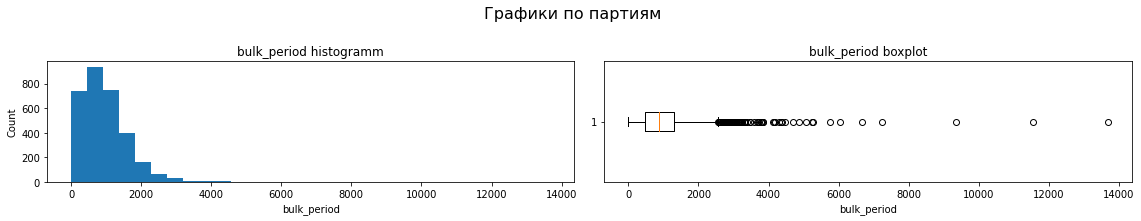

In [57]:
draw_hist_boxplot(
    bulk_time_features,
    'bulk_period',
    title='Графики по партиям',
    height_scale=1.5
)

Время между первой и последней подачей материала от 0 до 13683 секунд (0 секунд когда в партии подавался только один материал). Наблюдаем выбросы, могут объясняться длительным процессом, нет оснований считать аномальными.

**Сформирован датафрейм `bulk_time_features` с новыми признаками времени подачи сыпучих материалов**

### data_gas (объём подаваемого газа)

Изучим данные об объеме подаваемого газа

In [58]:
data_gas_df.columns

Index(['key', 'Газ 1'], dtype='object')

In [59]:
data_gas_df = data_gas_df.rename(columns={
    'key': 'key',
    'Газ 1': 'gas'
})
data_gas_df.columns

Index(['key', 'gas'], dtype='object')

In [60]:
df_info(data_gas_df)

**Размер датафрейма**

(3239, 2)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   gas     3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 0**

**Первые строки датафрейма**

,key,gas
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [61]:
data_gas_df['key'].duplicated().sum()

0

Типы корректны, Пропуски отсутствуют, каждой партии соответствует одна строка

In [62]:
data_gas_df[['gas']].describe().T

,count,mean,std,min,25%,50%,75%,max
gas,3239.0,11.002062,6.220327,0.008399,7.043089,9.836267,13.769915,77.99504


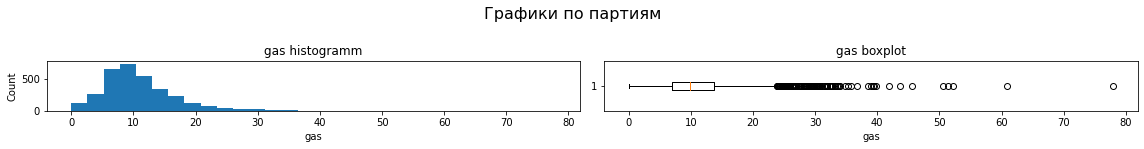

In [63]:
draw_hist_boxplot(
    data_gas_df,
    'gas',
    title='Графики по партиям'
)

Наблюдаются выбросы, оснований считать аномальными нет. Распределение скошено (вправо). 

### data_temp (данные об измерениях температуры)

Изучим данные об измерениях температуры

In [64]:
data_temp_df.columns

Index(['key', 'Время замера', 'Температура'], dtype='object')

In [65]:
data_temp_df = data_temp_df.rename(columns={
    'key': 'key',
    'Время замера': 'measure_time',
    'Температура': 'temperature'
})
data_temp_df.columns

Index(['key', 'measure_time', 'temperature'], dtype='object')

In [66]:
df_info(data_temp_df)

**Размер датафрейма**

(18092, 3)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   measure_time  18092 non-null  datetime64[ns]
 2   temperature   14665 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 424.2+ KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 3427**

**Первые строки датафрейма**

,key,measure_time,temperature
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


Тип данных `temperature` некорректен. Преобразуем.

In [67]:
data_temp_df['temperature'] = data_temp_df['temperature'].astype('float')

In [68]:
data_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   measure_time  18092 non-null  datetime64[ns]
 2   temperature   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


Наблюдаем пропуски в `temperature`. Значение первого замера температуры используем как входной признак, значение последнего как целевой. **Пропуски будем удалять после агрегации - если удалить их сейчас, то в качестве начальной температуры может оказаться не первый замер, а в качестве таргета не последний**

Согласно информации от заказчика, температура ниже 1500 аномальна. Удалим партии, для которых хотя бы в одном из замеров аномальная температура

In [69]:
with track_size('data_temp_df'):
    data_temp_df = data_temp_df[
        ~data_temp_df['key'].isin(
            data_temp_df[data_temp_df['temperature'] < 1500]['key']
        )
    ].reset_index(drop=True)

Датафрейм data_temp_df
Строк до: 18092
Строк после: 18065. Удалено 27


Поскольку нам нужны минимум два замера температуры, удалим партии, для которых менее двух наблюдений (то есть должны остаться только строки с дубликатами в `key`)

In [70]:
print(f'Партий, у которых менее двух замеров: {(data_temp_df.groupby("key").size() < 2).sum()}')

Партий, у которых менее двух замеров: 2


In [71]:
with track_size('data_temp_df'):
    data_temp_df = data_temp_df.groupby('key').filter(lambda x: len(x) >= 2).reset_index(drop=True)

Датафрейм data_temp_df
Строк до: 18065
Строк после: 18063. Удалено 2


In [72]:
data_temp_df.duplicated(subset='key', keep=False).sum() == data_temp_df.shape[0]

True

In [73]:
data_temp_df[['temperature']].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,14641.0,1590.864763,19.123035,1519.0,1580.0,1590.0,1599.0,1705.0


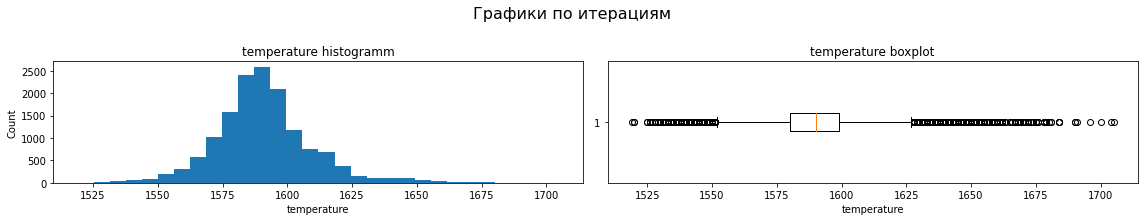

In [74]:
draw_hist_boxplot(
    data_temp_df,
    'temperature',
    title='Графики по итерациям',
    height_scale=1.5
)

Распределение похоже на нормальное, наблюдаются выбросы, аномалий не выявлено

Сргуппируем данные по партиям, сформировав признаки:
- `start_temperature` начальная температура
- `target` конечная температура (целевой признак)
- `first_measure_time` время первого замера температуры
- `last_measure_time` время последнего замера температуры
- `process_duraion` время между первым и последним замером температуры в секундах

In [75]:
data_temp_df = data_temp_df.sort_values(by=['key', 'measure_time'])

data_temp_grouped = data_temp_df.groupby('key').agg(
    start_temperature=('temperature', lambda x: x.iloc[0]),
    target=('temperature', lambda x: x.iloc[-1]),
    first_measure_time=('measure_time', 'first'),
    last_measure_time=('measure_time', 'last')
).reset_index()

data_temp_grouped['process_duration'] = (
    data_temp_grouped['last_measure_time'] - data_temp_grouped['first_measure_time']
).dt.total_seconds()

In [76]:
data_temp_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3209 entries, 0 to 3208
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   key                 3209 non-null   int64         
 1   start_temperature   3209 non-null   float64       
 2   target              2471 non-null   float64       
 3   first_measure_time  3209 non-null   datetime64[ns]
 4   last_measure_time   3209 non-null   datetime64[ns]
 5   process_duration    3209 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1)
memory usage: 150.5 KB


После группировки наблюдаем пропуски в `target`. Устраним соответствующие строки

In [77]:
with track_size('data_temp_grouped'):
    data_temp_grouped = data_temp_grouped.dropna(subset=['target']).reset_index(drop=True)

Датафрейм data_temp_grouped
Строк до: 3209
Строк после: 2471. Удалено 738


In [78]:
data_temp_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   key                 2471 non-null   int64         
 1   start_temperature   2471 non-null   float64       
 2   target              2471 non-null   float64       
 3   first_measure_time  2471 non-null   datetime64[ns]
 4   last_measure_time   2471 non-null   datetime64[ns]
 5   process_duration    2471 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1)
memory usage: 116.0 KB


Изучим сформированные признаки

In [79]:
data_temp_grouped[['start_temperature', 'target', 'process_duration']].describe().T

,count,mean,std,min,25%,50%,75%,max
start_temperature,2471.0,1589.012950,25.004369,1519.0,1572.0,1588.0,1605.0,1679.0
target,2471.0,1595.339943,16.035215,1541.0,1587.0,1593.0,1599.0,1700.0
process_duration,2471.0,2281.317685,1374.343709,339.0,1544.5,2007.0,2739.5,23674.0


In [80]:
data_temp_grouped.select_dtypes(include=['datetime64']).agg(['min', 'max']).T

,min,max
first_measure_time,2019-05-03 11:02:04,2019-08-10 13:33:21
last_measure_time,2019-05-03 11:30:38,2019-08-10 13:58:58


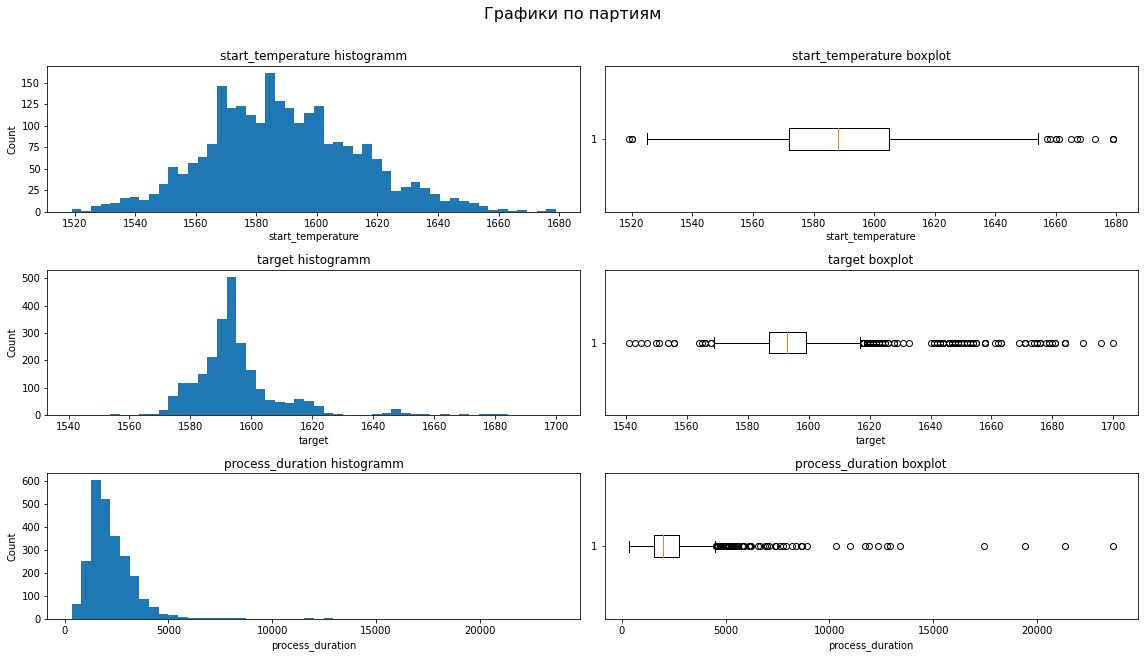

In [81]:
draw_hist_boxplot(
    data_temp_grouped,
    ['start_temperature', 'target', 'process_duration'],
    title='Графики по партиям',
    height_scale=1.5,
    bins=50
)

Наблюдаем выбросы.

Выбросы в `process_duration` с высокой продолжительностью в принципе соответствуют наблюдениям в данных о времени подачи материалов - некоторые партии длятся по неколько часов. Нет оснований считать аномалиями.

**Сформирован датафрейм `data_temp_grouped` с агрегированными по номеру партии признаками**

### data_wire (объём проволочных материалов)

Изучим данные об объёме проволочных материалов

In [82]:
data_wire_df.columns

Index(['key', 'Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5', 'Wire 6',
       'Wire 7', 'Wire 8', 'Wire 9'],
      dtype='object')

In [83]:
data_wire_df.columns = data_wire_df.columns.str.strip().str.replace(" ", "_").str.lower()
data_wire_df.columns

Index(['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6',
       'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

In [84]:
df_info(data_wire_df)

**Размер датафрейма**

(3081, 10)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   object 
 3   wire_3  63 non-null     object 
 4   wire_4  14 non-null     object 
 5   wire_5  1 non-null      object 
 6   wire_6  73 non-null     object 
 7   wire_7  11 non-null     object 
 8   wire_8  19 non-null     object 
 9   wire_9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 3081**

**Первые строки датафрейма**

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None
3,4,89.063515,None,None,None,None,None,None,None,None
4,5,89.238236,9.11456,None,None,None,None,None,None,None


Исправим типы данных на `float64`

In [85]:
obj_cols = data_wire_df.select_dtypes(include='object').columns
data_wire_df[obj_cols] = data_wire_df[obj_cols].astype('float')

In [86]:
data_wire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   float64
 3   wire_3  63 non-null     float64
 4   wire_4  14 non-null     float64
 5   wire_5  1 non-null      float64
 6   wire_6  73 non-null     float64
 7   wire_7  11 non-null     float64
 8   wire_8  19 non-null     float64
 9   wire_9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


Типы исправлены. Наблюдаем большое количество пропущенных значений. Пропуски означают, что материал не подавался (можем заменить нулями). Как и в `data_bulk` имеем признаки с очень большим количестом пропусков, действуем аналогично.

Удалим признак `wire_5` с единственным ненулевым значением

In [87]:
data_wire_df = data_wire_df.drop(columns=['wire_5'])

Изучим значения признаков

In [88]:
data_wire_df.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.000000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.918800,72.115684,100.158234,126.060483,330.314424
wire_2,1079.0,50.577323,39.320216,0.030160,20.193680,40.142956,70.227558,282.780152
wire_3,63.0,189.482681,99.513444,0.144144,95.135044,235.194977,276.252014,385.008668
wire_4,14.0,57.442841,28.824667,24.148801,40.807002,45.234282,76.124619,113.231044
wire_6,73.0,48.016974,33.919845,0.034320,25.053600,42.076324,64.212723,180.454575
wire_7,11.0,10.039007,8.610584,0.234208,6.762756,9.017009,11.886057,32.847674
wire_8,19.0,53.625193,16.881728,45.076721,46.094879,46.279999,48.089603,102.762401
wire_9,29.0,34.155752,19.931616,4.622800,22.058401,30.066399,43.862003,90.053604


In [89]:
data_wire_df['key'].duplicated().sum()

0

Все `key` уникальны, каждой партии соответствует одна строка.

Построим гистограммы и боксплоты. Строим графики без предварительного заполнения пропущенных значений нулями, чтобы увидеть распределения только в случаях, когда материал подавался.

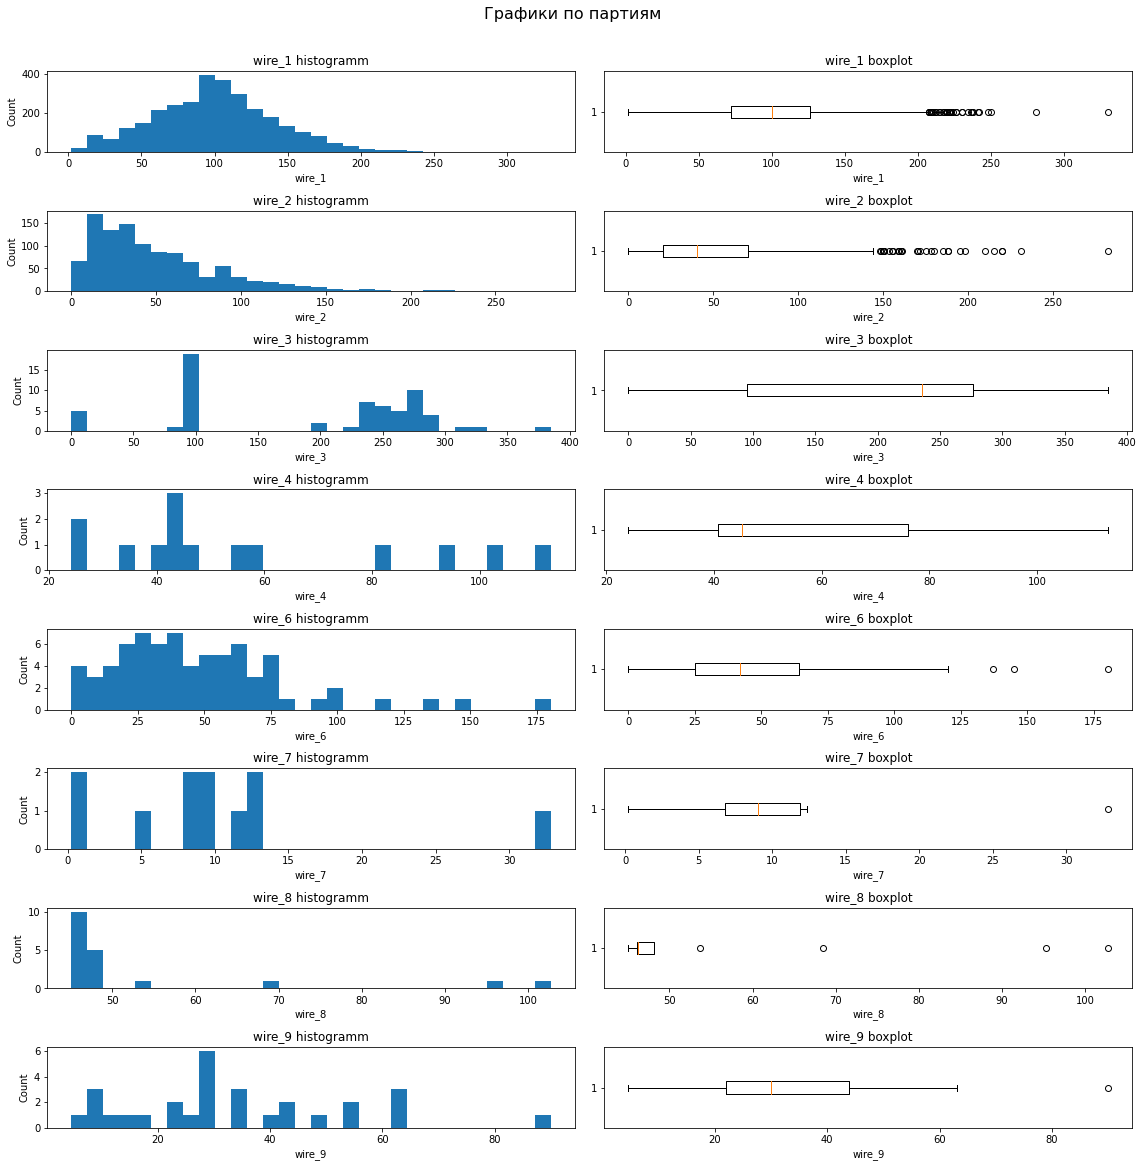

In [90]:
draw_hist_boxplot(
    data_wire_df,
    data_wire_df.columns.drop('key').tolist(),
    title='Графики по партиям'
)

Наблюдаем выбросы, причин считать аномальными нет.

**Пропуски на данном этапе не заполняем нулями, сделаем это в пайплайне**

### data_wire_time (время подачи проволочных материалов)

Изучим данные о времени подачи проволочных материалов

In [91]:
data_wire_time_df.columns

Index(['key', 'Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5', 'Wire 6',
       'Wire 7', 'Wire 8', 'Wire 9'],
      dtype='object')

In [92]:
data_wire_time_df.columns = data_wire_time_df.columns.str.strip().str.replace(" ", "_").str.lower()
data_wire_time_df.columns

Index(['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6',
       'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

In [93]:
df_info(data_wire_time_df)

**Размер датафрейма**

(3081, 10)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   wire_1  3055 non-null   object
 2   wire_2  1079 non-null   object
 3   wire_3  63 non-null     object
 4   wire_4  14 non-null     object
 5   wire_5  1 non-null      object
 6   wire_6  73 non-null     object
 7   wire_7  11 non-null     object
 8   wire_8  19 non-null     object
 9   wire_9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 3081**

**Первые строки датафрейма**

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None


Преобразуем типы к датам

In [94]:
date_cols = data_wire_time_df.columns.drop('key')

data_wire_time_df[date_cols] = data_wire_time_df[date_cols].apply(
    pd.to_datetime, errors='raise'
)

In [95]:
data_wire_time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   wire_1  3055 non-null   datetime64[ns]
 2   wire_2  1079 non-null   datetime64[ns]
 3   wire_3  63 non-null     datetime64[ns]
 4   wire_4  14 non-null     datetime64[ns]
 5   wire_5  1 non-null      datetime64[ns]
 6   wire_6  73 non-null     datetime64[ns]
 7   wire_7  11 non-null     datetime64[ns]
 8   wire_8  19 non-null     datetime64[ns]
 9   wire_9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


Наблюдаем большое количество пропусков

In [96]:
data_wire_time_df['key'].duplicated().sum()

0

Каждой партии соответствует одна строка

Сформируем датафрейм с признаками:

- `wire_first_time` время первой подачи материала
- `wire_last_time` время последней подачи материала
- `wire_period` время между первой и последней подачей материала в секундах

In [97]:
wire_time_features = data_wire_time_df[['key']].copy()

date_cols = data_wire_time_df.columns.drop('key')

wire_time_features['wire_first_time'] = data_wire_time_df[date_cols].min(axis=1)
wire_time_features['wire_last_time'] = data_wire_time_df[date_cols].max(axis=1)
wire_time_features['wire_period'] = (
    (wire_time_features['wire_last_time'] - wire_time_features['wire_first_time'])
    .dt.total_seconds()
)

Изучим сформированный датафрейм

In [98]:
df_info(wire_time_features)

**Размер датафрейма**

(3081, 4)

**Информация о датафрейме**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   key              3081 non-null   int64         
 1   wire_first_time  3081 non-null   datetime64[ns]
 2   wire_last_time   3081 non-null   datetime64[ns]
 3   wire_period      3081 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 96.4 KB


**Количество явных дубликатов строк: 0**

**Количество строк с пропущенными значениями: 0**

**Первые строки датафрейма**

,key,wire_first_time,wire_last_time,wire_period
0,1,2019-05-03 11:06:19,2019-05-03 11:06:19,0.0
1,2,2019-05-03 11:36:50,2019-05-03 11:36:50,0.0
2,3,2019-05-03 12:11:46,2019-05-03 12:11:46,0.0
3,4,2019-05-03 12:43:22,2019-05-03 12:43:22,0.0
4,5,2019-05-03 13:15:34,2019-05-03 13:20:44,310.0


Отсутствие пропусков говорит о том, что в каждой партии подавался хотя бы один материал

In [99]:
wire_time_features[['wire_period']].describe().T

,count,mean,std,min,25%,50%,75%,max
wire_period,3081.0,214.519312,396.131967,0.0,0.0,0.0,401.0,5937.0


In [100]:
wire_time_features.select_dtypes(include=['datetime64']).agg(['min', 'max']).T

,min,max
wire_first_time,2019-05-03 11:06:19,2019-09-06 17:10:06
wire_last_time,2019-05-03 11:06:19,2019-09-06 17:10:06


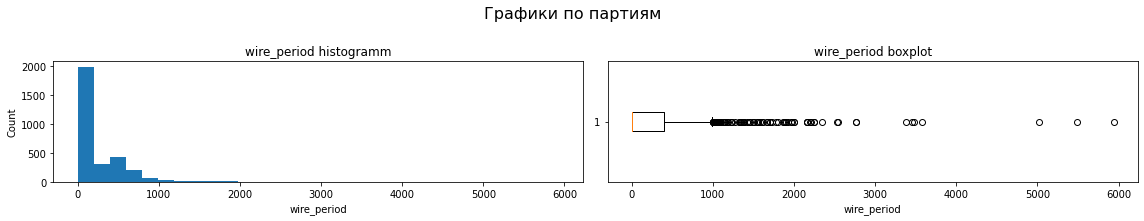

In [101]:
draw_hist_boxplot(
    wire_time_features,
    'wire_period',
    title='Графики по партиям',
    height_scale=1.5
)

Наблюдения схожы с теми, что были при изучении времени подачи сыпучих материалов. Время между первой и последней подачей материала от 0 до 5937 секунд (0 секунд когда в партии подавался только один материал). Наблюдаем выбросы, могут объясняться длительным процессом, нет оснований считать аномальными.

**Сформирован датафрейм `wire_time_features` с новыми признаками времени подачи сыпучих материалов**

### Итог

Обнаружено большое количество выбросов в данных, в основном обусловленных большим разбросом в продолжительности технологического процесса. Устранена партия с аномальным значением реактивной мощности, партии с аномальным значением температуры ниже 1500 градусов и те, где было произведено менее двух замеров температуры или последний замер имел пропущенное значение.

Пропуски в данных о количестве сыпучих и проволочных материалов означают их остутствие, будут заполняться нулями (в пайплайне)

Удалены признаки `bulk_8` и `wire_5` (имели лишь по одному ненулевому значению)

Для дальнейшего объединения подготовлены следующие датафреймы:

- `data_arc_grouped` сгруппированные данные о нагреве
  - `key` номер партии
  - `heat_duration` продолжительность нагрева
  - `active_energy` общая активная энергия партии
  - `reactive_energy` общая реактивная энергия партии
  - `heat_count` количество итераций нагрева
  - `heat_start_time` дата и время начала первого нагрева
  - `heat_end_time` дата и время окончания последнего нагрева
  - `active_power` средняя активная мощность
  - `reactive_power` средняя реактивная мощность
  - `total_power` средняя общая мощность
  - `power_rate` отношение активной мощности к реактивной
  - `total_energy` общая энергия
<br>

- `data_bulk_df` данные о количестве подаваемых сыпучих материалов
  - `key` номер партии
  - `bulk_1`,.., `bulk_7`, `bulk_9`,.., `bulk_15` количество подаваемых сыпучих материалов
<br>

- `bulk_time_features` данные о времени подачи сыпучих материалов
  - `key` номер партии
  - `bulk_first_time` дата и время первой подачи сыпучих материалов
  - `bulk_last_time` дата и время последней подачи сыпучих материалов
  - `bulk_period` время между первой и последней подачей сыпучих материалов
<br>

- `data_gas_df` данные об объеме подаваемого газа
  - `key` номер партии
  - `gas` общий объем подаваемого газа
<br>

- `data_temp_grouped` данные об измерениях температуры
  - `key` номер партии
  - `start_temperature` температура при первом замере
  - `target` температура при последнем замере (целевой признак)
  - `first_measure_time` дата и время первого замера температуры
  - `last_measure_time` дата и время последнего замера температуры
  - `process_duration` время между первым и последним замером температуры
<br>

- `data_wire_df` данные о количестве подаваемых проволочных материалов
  - `key` номер партии
  - `wire_1`,.., `wire_4`, `wire_6`,.., `wire_9` количество подаваемых проволочных материалов
<br>

- `wire_time_features` данные о времени подачи проволочных материалов
  - `key` номер партии
  - `wire_first_time` дата и время первой подачи проволочных материалов
  - `wire_last_time` дата и время последней подачи проволочных материалов
  - `wire_period` время между первой и последней подачей проволочных материалов


**Прим.:** возможно, имеет смысл рассмотреть вариант с объединением признаков легирующих материалов в один. Однако в этом проекте не делается, поскольку у нас отсутствует информация о размерности (там может быть как объем, так и масса, также может различаться масштаб) и о самих материалах (а именно об удельной теплоемкости)

## Объединение датафреймов

Осмотрим размеры датафреймов перед объединенем

In [102]:
sizes = {
    'data_arc_grouped': data_arc_grouped.shape[0],
    'data_bulk_df': data_bulk_df.shape[0],
    'bulk_time_features': bulk_time_features.shape[0],
    'data_gas_df': data_gas_df.shape[0],
    'data_temp_grouped': data_temp_grouped.shape[0],
    'data_wire_df': data_wire_df.shape[0],
    'wire_time_features': wire_time_features.shape[0],
}

pd.DataFrame.from_dict(sizes, orient='index', columns=['size'])

,size
data_arc_grouped,3213
data_bulk_df,3129
bulk_time_features,3129
data_gas_df,3239
data_temp_grouped,2471
data_wire_df,3081
wire_time_features,3081


Объединим датафреймы

In [103]:
data_df = (
    data_arc_grouped
    .merge(data_bulk_df, on='key', how='inner')
    .merge(bulk_time_features, on='key', how='inner')
    .merge(data_gas_df, on='key', how='inner')
    .merge(data_temp_grouped, on='key', how='inner')
    .merge(data_wire_df, on='key', how='inner')
    .merge(wire_time_features, on='key', how='inner')
)
data_df.shape[0]

2324

Объединенный датафрейм содержит 2324 строки. Следует заметить, что если бы мы не использовали `inner` соединение, то максимально возможный в теории размер не превысил бы 2471 (размер датафрейма с таргетом), но при этом мы бы получили пропущенные значения в информации о тех процессе.

## Исследовательский анализ. Продолжение.

Осмотрим данные

In [104]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2324 entries, 0 to 2323
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   key                 2324 non-null   int64         
 1   heat_duration       2324 non-null   float64       
 2   active_energy       2324 non-null   float64       
 3   reactive_energy     2324 non-null   float64       
 4   heat_count          2324 non-null   int64         
 5   heat_start_time     2324 non-null   datetime64[ns]
 6   heat_end_time       2324 non-null   datetime64[ns]
 7   active_power        2324 non-null   float64       
 8   reactive_power      2324 non-null   float64       
 9   total_power         2324 non-null   float64       
 10  power_rate          2324 non-null   float64       
 11  total_energy        2324 non-null   float64       
 12  bulk_1              199 non-null    float64       
 13  bulk_2              13 non-null     float64     

Ожидаемо наблюдаются пропуски в информации о количестве добавляемых легирующих материалов - будем заполнять нулями в пайплайне.

Проверим временные промежутки на корректность. Согласно тех процессу, первая подача легирующих материалов должна происходить только после первичного нагрева. Кроме того, все подачи материалов и нагревы ожидаются в промежуток от первого замера температуры до последнего.

In [105]:
bulk_before_heat = (data_df['bulk_first_time'] <= data_df['heat_start_time']).sum()
wire_before_heat = (data_df['wire_first_time'] <= data_df['heat_start_time']).sum()
print(f'bulk подан до первого нагрева: {bulk_before_heat}')
print(f'wire подан до первого нагрева: {wire_before_heat}')

heat_before_temp = (data_df['heat_start_time'] <= data_df['first_measure_time']).sum()
bulk_before_temp = (data_df['bulk_first_time'] <= data_df['first_measure_time']).sum()
wire_before_temp = (data_df['wire_first_time'] <= data_df['first_measure_time']).sum()
print(f'\nНагрев до первого замера: {heat_before_temp}')
print(f'bulk подан до первого замера: {bulk_before_temp}')
print(f'wire подан до первого замера: {wire_before_temp}')

heat_after_temp = (data_df['heat_end_time'] >= data_df['last_measure_time']).sum()
bulk_after_temp = (data_df['bulk_last_time'] >= data_df['last_measure_time']).sum()
wire_after_temp = (data_df['wire_last_time'] >= data_df['last_measure_time']).sum()

print(f'\nНагрев после финального замера: {heat_after_temp}')
print(f'bulk подан посе финального замера: {bulk_after_temp}')
print(f'wire подан после финального замера: {wire_after_temp}')

bulk подан до первого нагрева: 0
wire подан до первого нагрева: 0

Нагрев до первого замера: 0
bulk подан до первого замера: 0
wire подан до первого замера: 0

Нагрев после финального замера: 0
bulk подан посе финального замера: 0
wire подан после финального замера: 0


Временные промежутки корректны

Добавим признаки:

- `last_measure_heat_delay` время между последним замером и окончанием последнего нагрева в секундах
- `last_measure_bulk_delay` время между последним замером и последним добавлением сыпучих материалов в секундах
- `last_measure_wire_delay` время между последним замером и последним добавлением проволоки в секундах

In [106]:
data_df['last_measure_heat_delay'] = (data_df['last_measure_time'] - data_df['heat_end_time']).dt.total_seconds()
data_df['last_measure_bulk_delay'] = (data_df['last_measure_time'] - data_df['bulk_last_time']).dt.total_seconds()
data_df['last_measure_wire_delay'] = (data_df['last_measure_time'] - data_df['wire_last_time']).dt.total_seconds()

In [107]:
new_feats = ['last_measure_heat_delay', 'last_measure_bulk_delay', 'last_measure_wire_delay']
data_df[new_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
last_measure_heat_delay,2324.0,320.539587,357.013148,20.0,173.75,258.0,370.00,6963.0
last_measure_bulk_delay,2324.0,313.694492,392.962278,1.0,158.75,243.0,357.25,7029.0
last_measure_wire_delay,2324.0,1650.202238,1062.889664,87.0,1000.00,1469.5,2109.25,16653.0


Признаки даты и времени далее не понадобятся, для удобства сразу уберем

In [108]:
data_df = data_df.drop(columns=data_df.select_dtypes(include=['datetime64']).columns)

Визуализируем распределения. Ранее уже видели распределения объемов подаваемых материалов только в случаях подачи материала, на этот раз построим графики с учетом нулевых значений. Создадим временный датафрейм с заполненными nan значениями (также понадобится для корреляционного анализа)

In [109]:
data_df_tmp = data_df.fillna(0).copy()

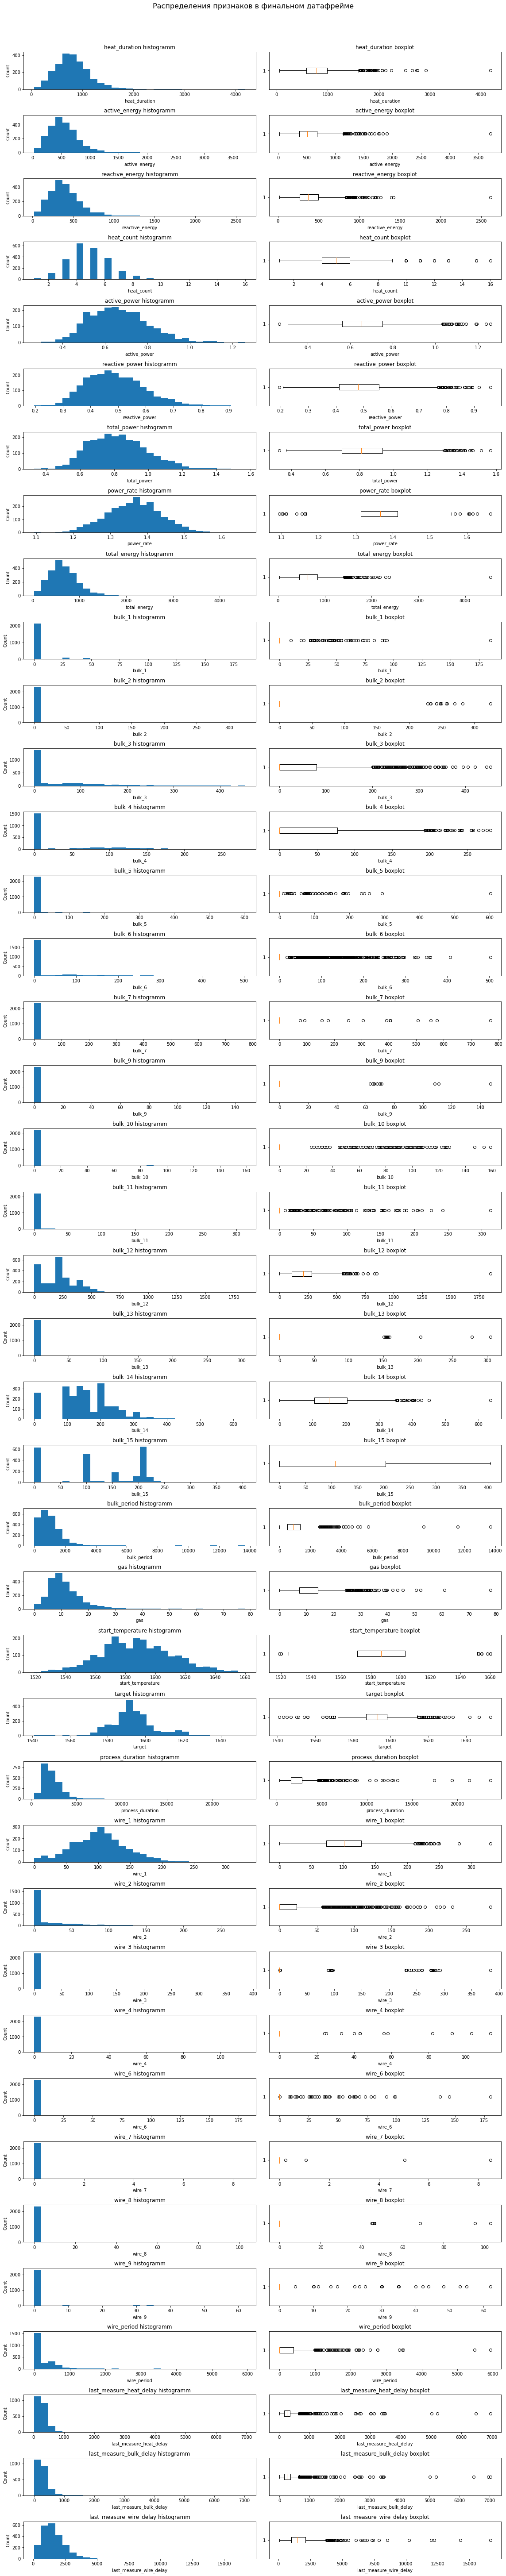

In [110]:
draw_hist_boxplot(
    data_df_tmp,
    data_df_tmp.columns.drop('key').tolist(),
    title='Распределения признаков в финальном датафрейме'
)

Большую часть распределений уже видели. У части признаков после заполнения пропусков ожидаемо преобладают нулевые значения.

У добавленных признаков `last_measure_heat_delay`, `last_measure_bulk_delay` и `last_measure_wire_delay` наблюдаются очень сильные выбросы. Объясняются тем, что последний замер температуры делался через несколько часов после окончания нагрева и последнего добавления легирующих материалов. Возможно, имело смысл более тщательно изучить хронологию и в качестве таргета брать более ранний замер (если таковой в наличии), однако поскольку в ТЗ требуется использовать последний из имеющихся, то оставляем так. Очевидно, сталь остывает, и задержка в измерении отразится на наблюдаемой температуре. Отсутствует информация о том, какую задержку во времени замера можно считать аномальной. Можем удалить наиболее сильные выбросы, однако не будем этого делать во избежание завышения оценки качества модели. Рекомендуется уточнение у заказчика информации о тех. процессе для понимания адекватных границ задержки во времени финального измерения температуры (необходимо понимание того, в какой момент времени заказчик хочет предсказывать температуру)

## Корреляционный анализ

Построим диаграммы рассеяния

In [111]:
def draw_scatter_plots(df: pd.DataFrame, cols: list[str], target_col='target'):
    nrows = math.ceil(len(cols) / 2)

    plt.figure(figsize=(14, nrows * 3))
    for i, col in enumerate(cols):
        plt.subplot(nrows, 2, i + 1)
        sns.scatterplot(data=df, x=col, y=target_col, alpha=0.4)

        plt.title(f'Scatter {col} vs {target_col}')
        plt.xlabel(col)
        plt.ylabel(target_col)

    plt.tight_layout()
    plt.show()

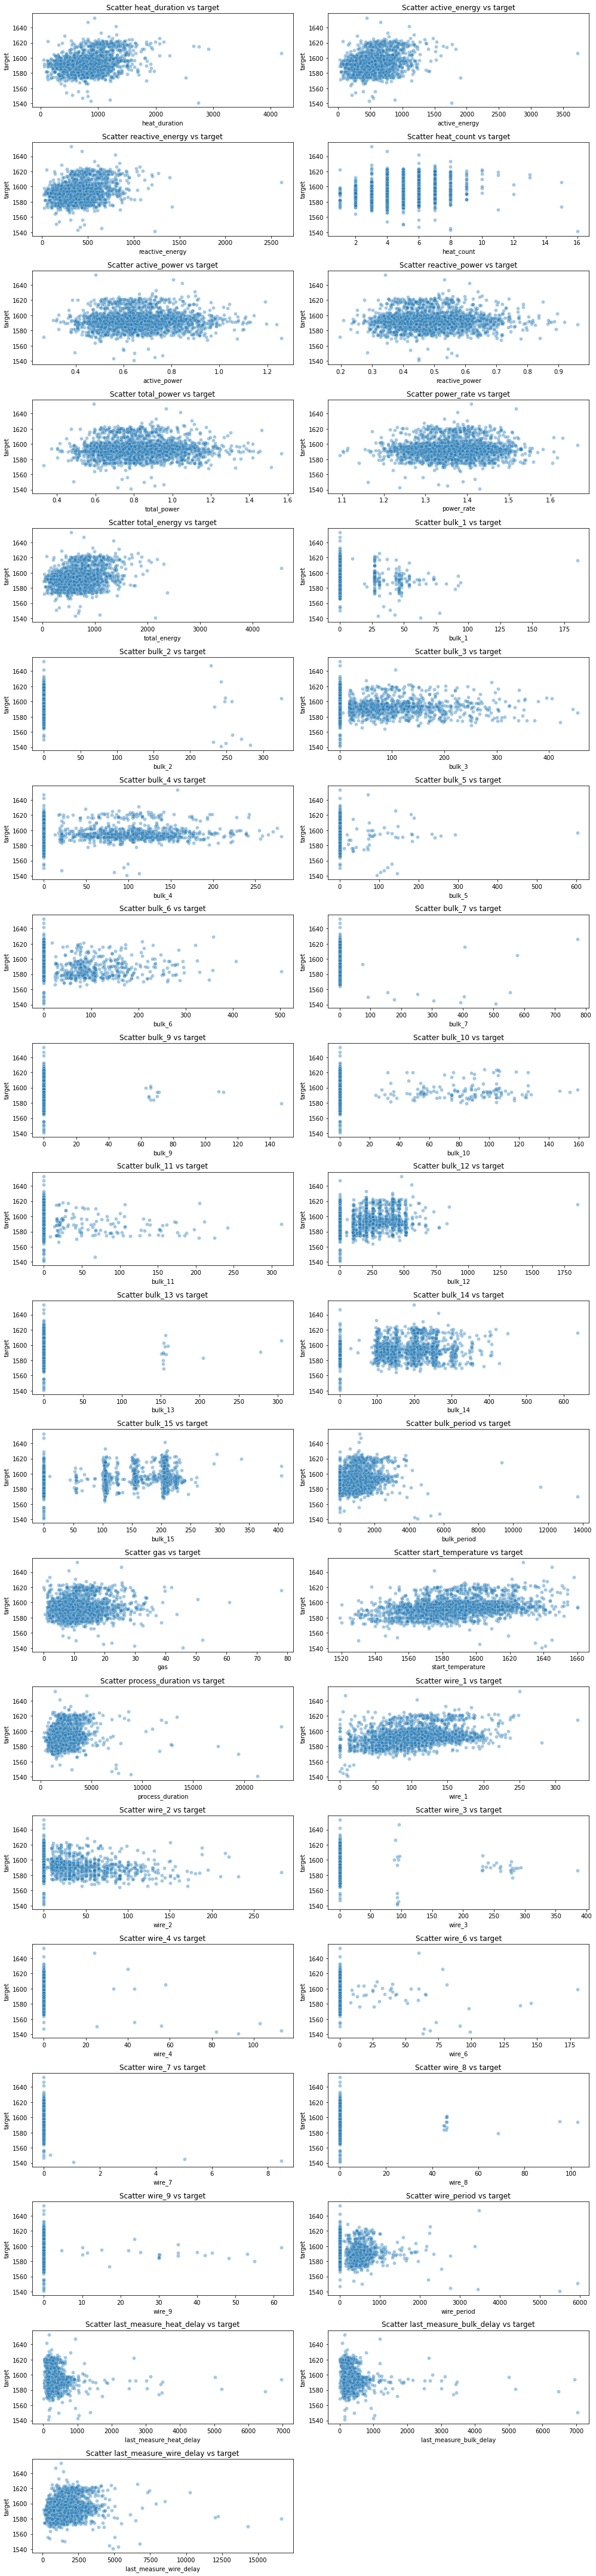

In [112]:
draw_scatter_plots(data_df_tmp, data_df_tmp.columns.drop(['key', 'target']))

Признаков довольно много, и смотреть на матрицу корреляций целиком проблематично. Рассмотрим отдельно корреляции обучающих признаков с таргетом и сильно скоррелированные пары обучающих признаков.

Корреляции между обучающими признаками и таргетом проверяем методом phik, чтобы увидеть нелинейные зависимости.

Между обучающими признаками смотрим на корреляцию Спирмена (поскольку нелинейные зависимости ничего не говорят о мультиколлинеарности, phik не подходит)

In [113]:
phik_matrix = data_df_tmp[
    data_df_tmp.columns.drop('key')
].phik_matrix(
    interval_cols=data_df_tmp.columns.drop(['key', 'heat_count'])
)

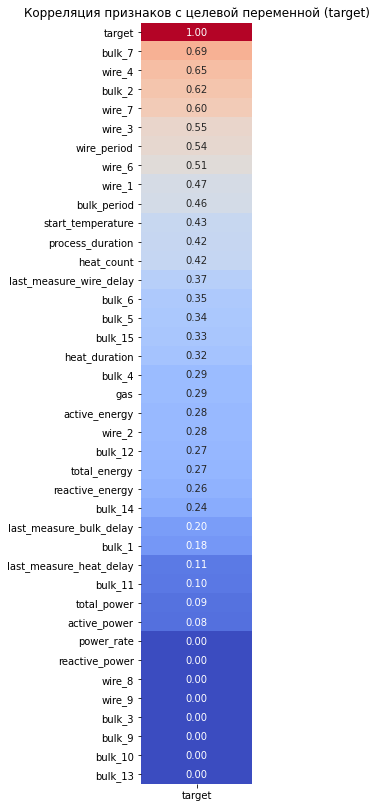

In [114]:
target_corr = phik_matrix[['target']].sort_values(by='target', ascending=False)

plt.figure(figsize=(2, 14))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('Корреляция признаков с целевой переменной (target)')
plt.show()

Можем видеть почти отсутствующие корреляции для части признаков объемов легирующих материалов. Следует заметить, что среди них есть не только признаки с очень большим количеством нулей (напр., `bulk_3` имеет примерно половину нулей). И сдругой стороны, `bulk_2` и `bulk_7` (для примера) имеют лишь по 13 ненулевых значений, но при этом сильные корреляции с таргетом. Это говорит в пользу решения сохранить признаки с редкими ненулевыми значениями.

In [115]:
def get_strong_pairs(df):
    corr_matrix = df[df.columns.drop(['key', 'target'])].corr(method='spearman')
    pairs = corr_matrix.unstack().reset_index()
    pairs.columns = ['Признак_1', 'Признак_2', 'Корреляция']
    pairs = pairs[pairs['Признак_1'] != pairs['Признак_2']]
    pairs['key_pair'] = pairs.apply(lambda row: '-'.join(sorted([row['Признак_1'], row['Признак_2']])), axis=1)
    pairs = pairs.drop_duplicates(subset=['key_pair']).drop(columns=['key_pair'])
    
    return pairs[pairs['Корреляция'] > 0.7].sort_values(by='Корреляция', ascending=False)

In [116]:
get_strong_pairs(data_df_tmp)

,Признак_1,Признак_2,Корреляция
657,bulk_9,wire_8,0.999996
47,active_energy,total_energy,0.999076
86,reactive_energy,total_energy,0.996951
162,active_power,total_power,0.995740
41,active_energy,reactive_energy,0.992773
1441,last_measure_heat_delay,last_measure_bulk_delay,0.992678
201,reactive_power,total_power,0.986745
161,active_power,reactive_power,0.967916
1,heat_duration,active_energy,0.885606
8,heat_duration,total_energy,0.884415


Видим, что очень сильная корреляция наблюдается у общей энергии с активной и реактивной, у общей мощности с активной и реактивной, между активной и реактивной энергией, между активной и реактивной мощностью.

По своей природе эти признаки не являются линейно зависимыми, наблюдаемая коллинеарность обсуловлена особенностью данных. Соотношение активной мощности к реактивной в наблюдаемой выборке имеет низкую дисперсию и колеблется в узком диапазоне (от 1.09 до 1.66), что объясняется конструкцией используемого оборудования. Это приводит к тому, что одна мощность почти линейно определяется другой. При этом общая мощность есть корень суммы квадратов активной и реактивной, но поскольку активная почти линейно выражается через реактивную, то и общая мощность практически линейно выражается через активную или реактивную. Если $k$ - соотношение активной ($P$) и реактивной ($Q$), то вычисление общей ($S$) превращается в $S = \sqrt{P^2 + Q^2} = \sqrt{(k*Q)^2 + Q^2} = \sqrt{k^2*Q^2 + Q^2} = \sqrt{(k^2 + 1) * Q^2} = Q * \sqrt{k^2 + 1}$. И поскольку $\sqrt{k^2 + 1}$ имеет меньший относительный разброс, чем $k$, то коллинеарность между общей мощностью и реактивной (или активной) еще более выражена, чем между активной и реактивной. Для энергии аналогично.

Также можем видеть коллинераность между `bulk_9` и `wire_8`. Это может объясняться как случайным совпадением в контексте малого количества наблюдений (оба материала добавлялись по 13 раз), так и особенностью технологического процесса (возможно, они добавляются всегда одновременно в определенной пропорции)

Хотя модели на основе деревьев решений и нейронные сети устойчивы к мультиколлинеарности, она может затруднить интерпретируемость признаков. Для снижения мультиколлинераности:

- устраним признаки энергии (энергия определяется как произведение мощности на время, деревянные модели и нейронная сеть могут выявить такие зависимости)
- устраним признак реактивной мощности (у нас есть признак соотношения активной и реактивной)
- устраним признак общей мощности

**Прим.:** были произведены попытки избавиться от мультиколлинеарности без удаления информации об общей мощности, например, найти разницу между отношением общей к реактивной и активной к реактивной. Хотя это позволяло устранить попарные коллинеарности, более сложные линейные зависимости все-равно оставались - видимо, обусловлено физикой и режимом работы оборудования. В конечном итоге решение об удалении принято с учетом экспериментов с моделями.

In [117]:
data_df_tmp = data_df_tmp.drop(columns=['total_energy', 'active_energy', 'reactive_energy', 'total_power', 'reactive_power'])

Повторно изучим попарные корреляции входных признаков

In [118]:
get_strong_pairs(data_df_tmp)

,Признак_1,Признак_2,Корреляция
402,bulk_9,wire_8,0.999996
1086,last_measure_heat_delay,last_measure_bulk_delay,0.992678
812,wire_2,wire_period,0.867753
195,bulk_2,wire_4,0.799770
747,process_duration,last_measure_wire_delay,0.796996
1,heat_duration,heat_count,0.772498
645,bulk_period,last_measure_wire_delay,0.766452
365,bulk_7,wire_4,0.720553


С коллинеарностью между `bulk_9` и `wire_8` ничего не делаем, поскольку отсутствует понимание природы признаков, необходимо уточнение у заказчика.

Также можем видеть коллинеарность между `last_measure_heat_delay` и `last_measure_bulk_delay` (устраним после анализа VIF)

Преобразования выполнены в копии датафрейма, повторим действия для датафрейма, который будет использоваться для обучения

In [119]:
data_df = data_df.drop(columns=['total_energy', 'active_energy', 'reactive_energy', 'total_power', 'reactive_power'])

По корреляциям можно судить лишь о частном случае мультиколлинеарности (коллинеарности векторов признаков попарно). Для выявления более общих случаев (когда признак приближенно выражается как линейная комбинация некольких признаков) рассчитаем фактор вздутия дисперсии (variance inflation error)

In [120]:
def get_vif(df):
    pearson_matrix = df[df.columns.drop(['key', 'target'])].corr()
    vif_values = np.linalg.inv(pearson_matrix.values).diagonal()
    vif_df = pd.DataFrame({'feature': pearson_matrix.columns, 'VIF': vif_values})
    return vif_df[vif_df.VIF > 5].sort_values('VIF', ascending=False).round(1)

In [121]:
get_vif(data_df_tmp)

,feature,VIF
28,wire_8,20.5
11,bulk_9,20.4
31,last_measure_heat_delay,11.2
32,last_measure_bulk_delay,10.9
21,process_duration,7.0
33,last_measure_wire_delay,5.9
0,heat_duration,5.5


Помимо `wire_8` и `bulk_9` видим мультиколлинераность (VIF больше 10) для признаков `last_measure_heat_delay` и `last_measure_bulk_delay` (а также слабую мультколлинеарность `process_duration`, `last_measure_wire_delay`, `heat_duration`). Удалим `last_measure_bulk_delay` и `last_measure_wire_delay` (для оценки задержки в замере температуры наиболее значимым выглядит `last_measure_heat_delay`)

In [122]:
data_df_tmp = data_df_tmp.drop(columns=['last_measure_wire_delay', 'last_measure_bulk_delay'])

In [123]:
get_vif(data_df_tmp)

,feature,VIF
28,wire_8,20.5
11,bulk_9,20.4
0,heat_duration,5.5


Повторим операцию для датафрейма, который будет использоваться для обучения

In [124]:
data_df = data_df.drop(columns=['last_measure_wire_delay', 'last_measure_bulk_delay'])

***Итог:*** Выявлена и устранена мультиколлинеарность для всех признаков, кроме `wire_8` и `bulk_9` (их не трогали из-за непонимания природы наблюдаемой мультиколлинеарности, необходимо уточнение у заказчика)

Удалены признаки `total_energy`, `active_energy`, `reactive_energy`, `total_power`, `reactive_power`, `last_measure_wire_delay`, `last_measure_bulk_delay`

***Прим.:*** Поскольку увеличение температуры определяется как отношение полученной энергии к произведению массы объекта на его удельную теплоемкойсть, то более рациональным выглядит использование признаков активной энергии вместо признаков мощности и продолжительности нагрева. Однако такой подход не используется в проекте, чтобы на этапе интерпретации можно было увидеть связь целевого признака с теми, котоыре имеем изначально (мощность, продолжительность нагрева)

## Подытог

In [125]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2324 entries, 0 to 2323
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   key                      2324 non-null   int64  
 1   heat_duration            2324 non-null   float64
 2   heat_count               2324 non-null   int64  
 3   active_power             2324 non-null   float64
 4   power_rate               2324 non-null   float64
 5   bulk_1                   199 non-null    float64
 6   bulk_2                   13 non-null     float64
 7   bulk_3                   958 non-null    float64
 8   bulk_4                   811 non-null    float64
 9   bulk_5                   53 non-null     float64
 10  bulk_6                   437 non-null    float64
 11  bulk_7                   13 non-null     float64
 12  bulk_9                   13 non-null     float64
 13  bulk_10                  143 non-null    float64
 14  bulk_11                 

Для обучения моделей сформирован датафрейм data_df со следующими признаками:

- `key` номер партии
- `heat_duration` продолжительность нагрева
- `heat_count` количество итераций нагрева
- `active_power` средняя активная мощность
- `power_rate` отношение активной мощности к реактивной
- `bulk_1`,.., `bulk_7`, `bulk_9`,.., `bulk_15` количество подаваемых сыпучих материалов
- `bulk_period` время между первой и последней подачей сыпучих материалов
- `gas` общий объем подаваемого газа
- `start_temperature` температура при первом замере
- **`target`** температура при последнем замере (**целевой признак**)
- `process_duration` время между первым и последним замером температуры
- `wire_1`,.., `wire_4`, `wire_6`,.., `wire_9` количество подаваемых проволочных материалов
- `wire_period` время между первой и последней подачей проволочных материалов
- `last_measure_heat_delay` промежуток времени между окончанием последнего нагрева и финальным замером температуры

## Обучение моделей

В качестве метрики качества согласно ТЗ используем MAE

### Подготовка данных

In [126]:
X = data_df.drop(columns=['key', 'target'])
y = data_df['target']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

Создадим список колонок, для которых пропуски заполняются нулями

In [128]:
fill_zero_cols = [
    c for c in X_train.columns 
    if (c.startswith('bulk_') and c.split('_')[1].isdigit()) or 
       (c.startswith('wire_') and c.split('_')[1].isdigit())
]
fill_zero_cols

['bulk_1',
 'bulk_2',
 'bulk_3',
 'bulk_4',
 'bulk_5',
 'bulk_6',
 'bulk_7',
 'bulk_9',
 'bulk_10',
 'bulk_11',
 'bulk_12',
 'bulk_13',
 'bulk_14',
 'bulk_15',
 'wire_1',
 'wire_2',
 'wire_3',
 'wire_4',
 'wire_6',
 'wire_7',
 'wire_8',
 'wire_9']

Остальные признаки пропусков не имеют, исходим из того, что там их быть не может (**необходимо уточнение у заказчика**)

In [129]:
metrics = {}
metrics_std = {}

### Случайный лес

In [130]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0.0), fill_zero_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
preprocessor_rf.set_output(transform='pandas')

pipe_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor_rf),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE)),
    ]
)

param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 10, 15],
}


grid_search = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_mae = -grid_search.best_score_
best_index = grid_search.best_index_
best_std = grid_search.cv_results_['std_test_score'][best_index]

metrics['Random Forest'] = best_mae
metrics_std['Random Forest'] = best_std

print('Лучшие параметры:', grid_search.best_params_)
print(f'Лучшая MAE на кроссвалидации: {best_mae:.3f}')
print(f'Стандартное отклонение лучшей MAE на кроссвалидации: {best_std:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Лучшая MAE на кроссвалидации: 6.115
Стандартное отклонение лучшей MAE на кроссвалидации: 0.4543


### Catboost

In [131]:
preprocessor_cb = ColumnTransformer(
    transformers=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0.0), fill_zero_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
preprocessor_cb.set_output(transform='pandas')

X_train_processed = preprocessor_cb.fit_transform(X_train)

model_cb = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=2500,
    random_seed=RANDOM_STATE,
    early_stopping_rounds=100,
    verbose=False
)


param_grid_cb = {
    'depth': [2, 3, 5],
    'l2_leaf_reg': [None, 1, 5, 10],
    'subsample': [0.3, 0.5, 0.7, 1.0]
}

grid_search_result = model_cb.grid_search(
    param_grid_cb,
    X=X_train_processed,
    y=y_train,
    cv=5,
    partition_random_seed=RANDOM_STATE,
    verbose=False
)

best_mae = min(grid_search_result['cv_results']['test-MAE-mean'])
best_index = np.argmin(grid_search_result['cv_results']['test-MAE-mean'])
best_std = grid_search_result['cv_results']['test-MAE-std'][best_index]

metrics['CatBoost'] = best_mae
metrics_std['CatBoost'] = best_std

print(f'Лучшие параметры: {grid_search_result["params"]}')
print(f'Лучшая MAE на кроссвалидации: {best_mae:.3f}')
print(f'Стандартное отклонение лучшей MAE на кроссвалидации: {best_std:.4f}')

Stopped by overfitting detector  (100 iterations wait)

bestTest = 6.009661267
bestIteration = 1558

Stopped by overfitting detector  (100 iterations wait)

bestTest = 5.948243765
bestIteration = 2288

Stopped by overfitting detector  (100 iterations wait)

bestTest = 5.905846174
bestIteration = 2057

Stopped by overfitting detector  (100 iterations wait)

bestTest = 6.325665941
bestIteration = 2032

Stopped by overfitting detector  (100 iterations wait)

bestTest = 6.385104134
bestIteration = 1189

Stopped by overfitting detector  (100 iterations wait)

bestTest = 6.246178714
bestIteration = 1259

Stopped by overfitting detector  (100 iterations wait)

bestTest = 7.950035218
bestIteration = 949

Stopped by overfitting detector  (100 iterations wait)

bestTest = 7.997093481
bestIteration = 1445

Stopped by overfitting detector  (100 iterations wait)

bestTest = 8.284238744
bestIteration = 974

Stopped by overfitting detector  (100 iterations wait)

bestTest = 6.045726355
bestIteration 

### Нейронная сеть

In [132]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)

In [133]:
preprocessor_nn = Pipeline(
    steps=[
        (
            'imputer',
            ColumnTransformer(
                transformers=[
                    (
                        'impute_zero',
                        SimpleImputer(strategy='constant', fill_value=0.0),
                        fill_zero_cols,
                    ),
                ],
                remainder='passthrough'
            ),
        ),
        ('to_float32', FunctionTransformer(lambda x: x.astype('float32'))),
        ('scaler', StandardScaler()),
    ]
)

In [134]:
class PlotLossCallback(Callback):
    """Callback для динамической отрисовки графиков функции потерь."""
    def on_train_begin(self, net, **kwargs):
        self.fig, self.ax = plt.subplots(figsize=(10, 5))

        self.line_train, = self.ax.plot([], [], label='Train Loss', color='blue')
        self.line_valid, = self.ax.plot([], [], label='Validation Loss', color='orange')

        self.loss_text = self.ax.text(
            0.97,
            0.82,
            '',
            transform=self.ax.transAxes,
            ha='right',
            va='top',
            fontsize=11,
            fontweight='bold',
            bbox=dict(boxstyle="round", facecolor='white', alpha=0.8, edgecolor='gray'),
        )
        
        self.ax.set_title('Обучение модели')
        self.ax.set_xlabel('Эпохи')
        self.ax.set_ylabel('Loss')
        self.ax.legend()
        self.ax.grid(True)
        self.fig.tight_layout()
        
        self.display_handle = display(self.fig, display_id=True)

    def on_epoch_end(self, net, **kwargs):
        history = net.history
        train_loss = history[:, 'train_loss']
        valid_loss = history[:, 'valid_loss']
        epochs = list(range(1, len(train_loss) + 1))
        
        self.line_train.set_data(epochs, train_loss)
        self.line_valid.set_data(epochs, valid_loss)

        current_train = train_loss[-1]
        current_valid = valid_loss[-1]
        text_content = f'Train MAE: {current_train:.3f}\nValid MAE: {current_valid:.3f}'
        self.loss_text.set_text(text_content)
        
        self.ax.relim()
        self.ax.autoscale_view()

        self.display_handle.update(self.fig)
        
    def on_train_end(self, net, **kwargs):
        plt.close(self.fig)

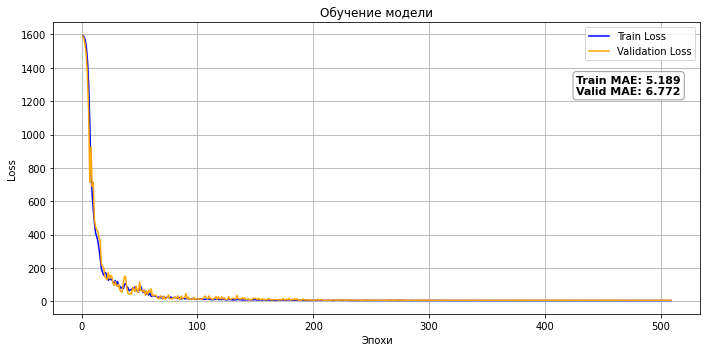

Лучшая MAE на валидации: 6.364


In [135]:
class Net(nn.Module):
    def __init__(self, input_dim=20):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),

            nn.Linear(64, 16),
            nn.SiLU(),

            nn.Linear(16, 1)
        )
        
    def forward(self, X):
        return self.net(X).squeeze(-1)


model_nn = NeuralNetRegressor(
    module=Net,
    module__input_dim=X_train.shape[1],
    max_epochs=1000,
    lr=1e-2,
    criterion=nn.L1Loss,
    optimizer=torch.optim.AdamW,
    optimizer__weight_decay=0.12,
    iterator_train__shuffle=True,
    train_split=ValidSplit(cv=5),
    callbacks=[
        ('early_stopping', EarlyStopping(load_best=True, patience=200)),
        ('lr_scheduler', LRScheduler(policy='ReduceLROnPlateau', factor=0.5, min_lr=1e-4, patience=20)),
        ('live_plot', PlotLossCallback())
    ],
    device=DEVICE,
    verbose=0
)

pipe_nn = Pipeline(
   steps=[
       ('preprocessor', preprocessor_nn),
       ('model', model_nn),
   ]
)

pipe_nn.fit(X_train, y_train)

best_mae = min(pipe_nn.named_steps['model'].history[:, 'valid_loss'])

metrics['Net'] = best_mae
metrics_std['Net'] = None

print(f'Лучшая MAE на валидации: {best_mae:.3f}')

### Дамми-модель

In [136]:
dummy_model = DummyRegressor(strategy='mean')

cv_scores_dummy = cross_val_score(estimator=dummy_model, X=X_train, y=y_train, cv=5, scoring='neg_mean_absolute_error')

dummy_mae = -cv_scores_dummy.mean()
metrics['Dummy'] = dummy_mae
metrics_std['Dummy'] = None

print(f'MAE дамми-модели на кроссвалидации: {dummy_mae:.3f}')

MAE дамми-модели на кроссвалидации: 8.070


## Сравнение моделей

In [137]:
(pd.DataFrame([metrics], index=['MAE']).T).join(pd.DataFrame([metrics_std], index=['STD']).T)

,MAE,STD
Random Forest,6.114914,0.454272
CatBoost,5.902195,0.237516
Net,6.363996,None
Dummy,8.069783,None


**Лучший результат показал регрессор CatBoost. MAE на кроссвалидации составил 5.9, что на 2.1 лучше предсказывающей среднее дамми модели**

## Тестирование

Протестируем лучшую модель (CatBoost)

In [138]:
X_test_proc = preprocessor_cb.transform(X_test)
preds = model_cb.predict(X_test_proc)

In [139]:
def calculate_metrics(y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    residuals = predictions - y_test
    residuals_mean = residuals.mean()
    quantile_2_5 = np.quantile(residuals, 0.025)
    quantile_97_5 = np.quantile(residuals, 0.975)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
    axes[0].hist(residuals, bins=50)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')
    axes[1].scatter(predictions, residuals, alpha=0.5)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    axes[1].set_title('Анализ дисперсии')
    plt.show()

    print(f'MAE={mae:.3f}')
    print(f'R2={r2:.3f}')
    print(f'Mean residual = {residuals_mean:.2f}')
    print(
        'Доверительный интервал прогноза модели (2.5%-97.5% квантили ошибок)'
        f': [{quantile_2_5:.2f}, {quantile_97_5:.2f}]'
    )

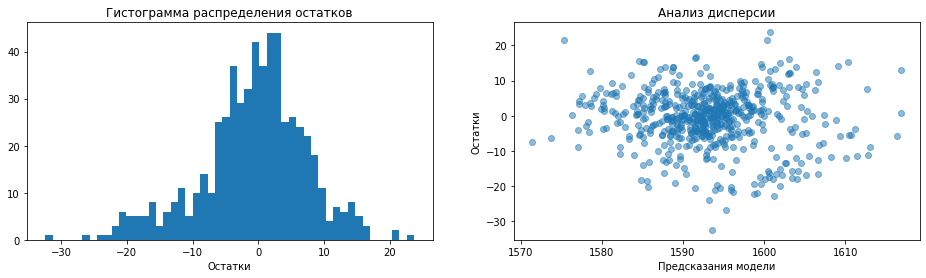

MAE=6.014
R2=0.476
Mean residual = -0.68
Доверительный интервал прогноза модели (2.5%-97.5% квантили ошибок): [-19.56, 13.84]


In [140]:
calculate_metrics(y_test, preds)

**На тестовой выборке MAE составила 6. Метрика R2 0.47 говорит о том, что модель объясняет 47% дисперсии температуры. Модель склонна недооценивать температуру в среднем на 0.68 градуса (довольно незначительное смещение с учетом масштаба признака). Распределение остатков похоже на нормальное, дисперсия остатков равномерная. Можем наблюдать пару выбросов.**

**95% ошибок модели находятся в диапазоне от -19 до +13 градусов.**

## Интерпретация

Оценим важность признаков

In [141]:
shap_values = model_cb.get_feature_importance(
    data=Pool(X_test_proc), 
    type='ShapValues'
)
shap_values = shap_values[:, :-1]

/tmp/ipykernel_142/1655413815.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


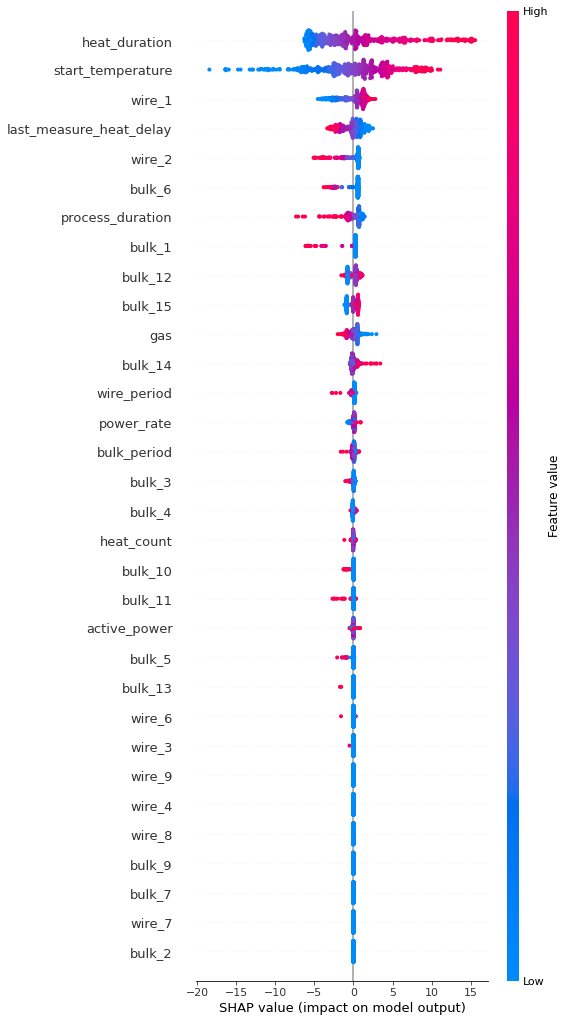

In [142]:
%matplotlib inline
shap.summary_plot(
    shap_values,
    X_test_proc,
    max_display=40
)

Наибольшее влияние на конечную температуру оказывают продолжительность нагрева и начальная температура - более высокие значения этих признаков говорят о более высокой итоговой температуре.

Также заметное влияние оказывают задержка между окончанием последнего нагрева и финальным замером температуры - ожидаемо, поскольку сталь постоянно остывает.

Более высокая продолжительность процесса также говорит о более низкой итоговой температуре, что скорее всего также связано с задержкой финального замера температуры.

Большие объемы добавляемого газа приводят к более низкой итоговой температуре. Аналогично более высокие объемы легируюих материалов приводят также к более низкой температуре.

Активная мощность и соотношение активной мощности к реактивной оказались в середине по значимости (действуют в сторону повышения температуры)

Среди добавляемых сыпучих материалов наибольшее влияние оказали:
- bulk_6 (437 ненулевых)
- bulk_12 (1809 ненулевых)
- bulk_1 (199 ненулевых)
- bulk_15 (1696 ненулевых)
- bulk_14 (2064 ненулевых)

Наименьшее:
- bulk_2 (13 ненулевых)
- bulk_9 (13 ненулевых)
- bulk_5 (53 ненулевых)

Среди добавляемых проволочных материалов наибольшее влияние оказали:
- wire_1 (2301 ненулевых)
- wire_2 (809 ненулевых)

Наименьшее:
- wire_8 (13 ненулевых)
- wire_4 (12 ненулевых)
- wire_7 (4 ненулевых)
- wire_9 (24 ненулевых)
- wire_3 (39 ненулевых)

То есть наиболее редкие материалы оказали наименьшее влияние. Однако следует понимать, что это слабое влияние скорее обусловлено именно их редкостью в имеющемся наборе данных, а не природой самих признаков.

Дополнительно отобразим график зависомсти итоговой температуры от наиболее значимого признака

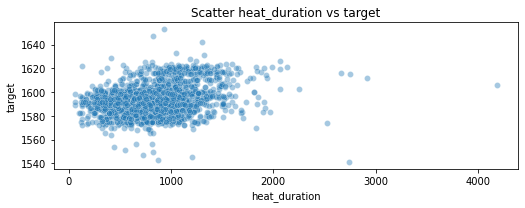

In [143]:
draw_scatter_plots(data_df_tmp, ['heat_duration'])

## Вывод

На основе исходных данных был сформирован датасет с 2324 записями.

В данных обнаружено большое количество выбросов, в основном обусловленных большим разбросом в продолжительности технологического процесса. Устранена партия с аномальным значением реактивной мощности, партии с аномальным значением температуры ниже 1500 градусов и те, где было произведено менее двух замеров температуры или последний замер имел пропущенное значение. Признаки `wire_5` и `bulk_8` имели лишь по одному ненулевому значению, были удалены. 

Для предсказания итоговой температуры были обучены три модели - случайный лес, гаридентный бустинг (регрессор CatBoost) и нейронная сеть. **Лучший результат показал регрессор CatBoost**.

Лучшая модель показала метрику **MAE 6**, что на **2** лучше константной модели. Модель **объясняет 47% дисперсии** температуры и имеет равномерное распределение ошибок. 95% ошибок модели находятся в диапазоне от -19 до +13 градусов.

Наибольшее влияние на конечную температуру оказывают продолжительность нагрева и начальная температура партии.

Некоторые легирующие материалы согласно имеющейся выборке данных подавались очень редко, что снизило их значимость для модели. Рекомендуется увеличение размера выборки для более точной оценки их влияния. Также было обнаружено, что масса подаваемых материалов `wire_8` и `bulk_9` линейно зависима - необходимо уточнение, явялется ли это случайностью или особенностью технологического процесса.

Имеет смысл рассмотреть подход, при котором в качестве признака будут подаваться не массы (объемы) отдельных материалов, а их суммарная масса. В идеале при таком подходе необходима точная информация о материалах, чтобы учесть их различную удельную теплоемкость.

Также рекомендуется уточнение у заказчика информации о тех. процессе для понимания адекватных границ задержки во времени финального измерения температуры (необходимо понимание того, в какой момент времени заказчик хочет предсказывать температуру)

Возможно, имеет смысл добавить ко входных признакам температуру оружающей среды, так как она может влиять и на скорость остывания стали, и на начальную температуру добавляемых материалов. Информация о температуре подаваемого газа тоже может быть полезна.